In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
import scipy.cluster.hierarchy as sch
from scipy.stats import spearmanr, linregress,kendalltau

In [35]:
cell_types=["Tcells","Bcells",	"NKcells", "Macrophages","Mast cells", "DCs", "other", "Endothelial cells"]
target_CAFs=["FAP", "PDGFRA", "PDGFRB", "S100A4", "LRRC15", "IL1R1", "IL1R2","SMO"]
target_receptors_molecules=["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]

In [36]:
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/fibroblasts_gene_expression_data_new_batch_merged_with_metadata.csv")
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified.head(5)

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,UMAP1_harmony_batch_corr,UMAP2_harmony_batch_corr,tSNE1_harmony_batch_corr,tSNE2_harmony_batch_corr,PFS_quartile,OS_quartile,HRP_status,BRCA_status,PFS_quartile_b12,OS_quartile_b12
0,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,1.215215,-0.077432,-3.170091,-5.679086,1.0,1.0,1.0,0.0,2.0,1.0
1,DSP-1001660016604-A-A03.dcc,1.260101,1.487834,1.372068,0.897518,1.051446,1.981081,4.439861,1.858659,-0.088057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DSP-1001660016604-A-A04.dcc,1.224783,1.724003,1.333149,1.528053,-0.045955,1.932914,5.415247,1.805880,-0.088144,...,1.018313,0.150165,-3.133863,-5.250586,1.0,1.0,1.0,0.0,2.0,1.0
3,DSP-1001660016604-A-A05.dcc,1.032495,1.168011,1.440325,0.954786,-0.044855,1.752843,5.293798,1.926242,-0.088061,...,1.391849,0.083829,-3.781880,-5.211237,1.0,1.0,1.0,0.0,2.0,1.0
4,DSP-1001660016604-A-A06.dcc,0.885513,1.403719,0.997214,1.190924,-0.044885,2.324255,5.864764,1.482811,-0.088064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df_cell_abundance = pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_bp_res_mid_lvl_ct_ct_fraction.csv")
fibr_gene_expression_cell_abundance=fibr_gene_expression_modified.merge(df_cell_abundance, on="dcc_filename", how="left")
fibr_gene_expression_cell_abundance.head(5)

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Endothelial cells,Roi_y,Segment_y,Sample_y,NACT_status_y,Annotation_cell_y,Roi.1,Segment_geomx,Patient_y,Site_y
0,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,0.028128,1.0,stroma,S130_iOme,post,CD8_Iba1,NaN,tsi,S130,Omentum
1,DSP-1001660016604-A-A03.dcc,1.260101,1.487834,1.372068,0.897518,1.051446,1.981081,4.439861,1.858659,-0.088057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DSP-1001660016604-A-A04.dcc,1.224783,1.724003,1.333149,1.528053,-0.045955,1.932914,5.415247,1.805880,-0.088144,...,0.029949,2.0,stroma,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum
3,DSP-1001660016604-A-A05.dcc,1.032495,1.168011,1.440325,0.954786,-0.044855,1.752843,5.293798,1.926242,-0.088061,...,0.029244,2.0,tumor,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum
4,DSP-1001660016604-A-A06.dcc,0.885513,1.403719,0.997214,1.190924,-0.044885,2.324255,5.864764,1.482811,-0.088064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
sample_metadata= fibr_gene_expression_cell_abundance[["Sample_y"]].drop_duplicates().set_index("Sample_y")
stroma_cell_abundance=fibr_gene_expression_cell_abundance[fibr_gene_expression_modified['Segment']=='stroma']
average_stroma_cell_abundance=stroma_cell_abundance.groupby('Sample_y')[cell_types+target_CAFs+target_receptors_molecules].mean()
average_stroma_cell_abundance = average_stroma_cell_abundance.join(sample_metadata,how="inner")
average_stroma_cell_abundance.head(5)

,Tcells,Bcells,NKcells,Macrophages,Mast cells,DCs,other,Endothelial cells,FAP,PDGFRA,...,FGF10,FGFR1,FGFR2,FGFR3,FGFR4,IL11,HAS1,HAS2,HYAL1,HYAL2
Sample_y,,,,,,,,,,,,,,,,,,,,,
S015_post,0.035728,0.008453,0.041546,0.110280,0.002399,0.028474,0.004122,0.017189,4.207266,4.373742,...,2.578220,3.205101,0.991744,0.299681,0.508378,1.980160,2.647840,2.295521,1.431089,1.860142
S015_pre,0.014464,0.006668,0.043704,0.088342,0.002538,0.027931,0.004545,0.016157,4.691707,4.062607,...,3.223099,2.882796,1.556014,0.717385,1.002197,2.554963,3.242793,2.690586,1.735281,2.179100
S027_post,0.034365,0.045222,0.047738,0.093674,0.001678,0.039142,0.004622,0.025143,4.339291,4.852624,...,3.461966,3.409909,0.610212,0.239314,1.480520,2.641902,3.353829,2.813274,1.622922,2.135830
S027_pre,0.026960,0.011836,0.020134,0.170804,0.001072,0.019188,NaN,0.015858,3.991612,3.689627,...,1.944959,2.505830,1.168566,0.375664,-0.198721,1.660973,2.341774,1.860757,1.249905,2.273118
S032_post,0.039059,0.030397,0.019808,0.209957,0.001367,0.034192,NaN,0.011721,4.170236,3.908524,...,2.720472,2.644436,1.112555,0.421874,0.060000,1.831252,2.667713,2.127929,1.384202,1.895738


Spearman correlation for FAP vs Tcells: 0.04
Spearman correlation for PDGFRA vs Tcells: 0.21
Spearman correlation for PDGFRB vs Tcells: 0.10
Spearman correlation for S100A4 vs Tcells: -0.44
Spearman correlation for LRRC15 vs Tcells: 0.10
Spearman correlation for IL1R1 vs Tcells: -0.06
Spearman correlation for IL1R2 vs Tcells: -0.19
Spearman correlation for SMO vs Tcells: -0.26


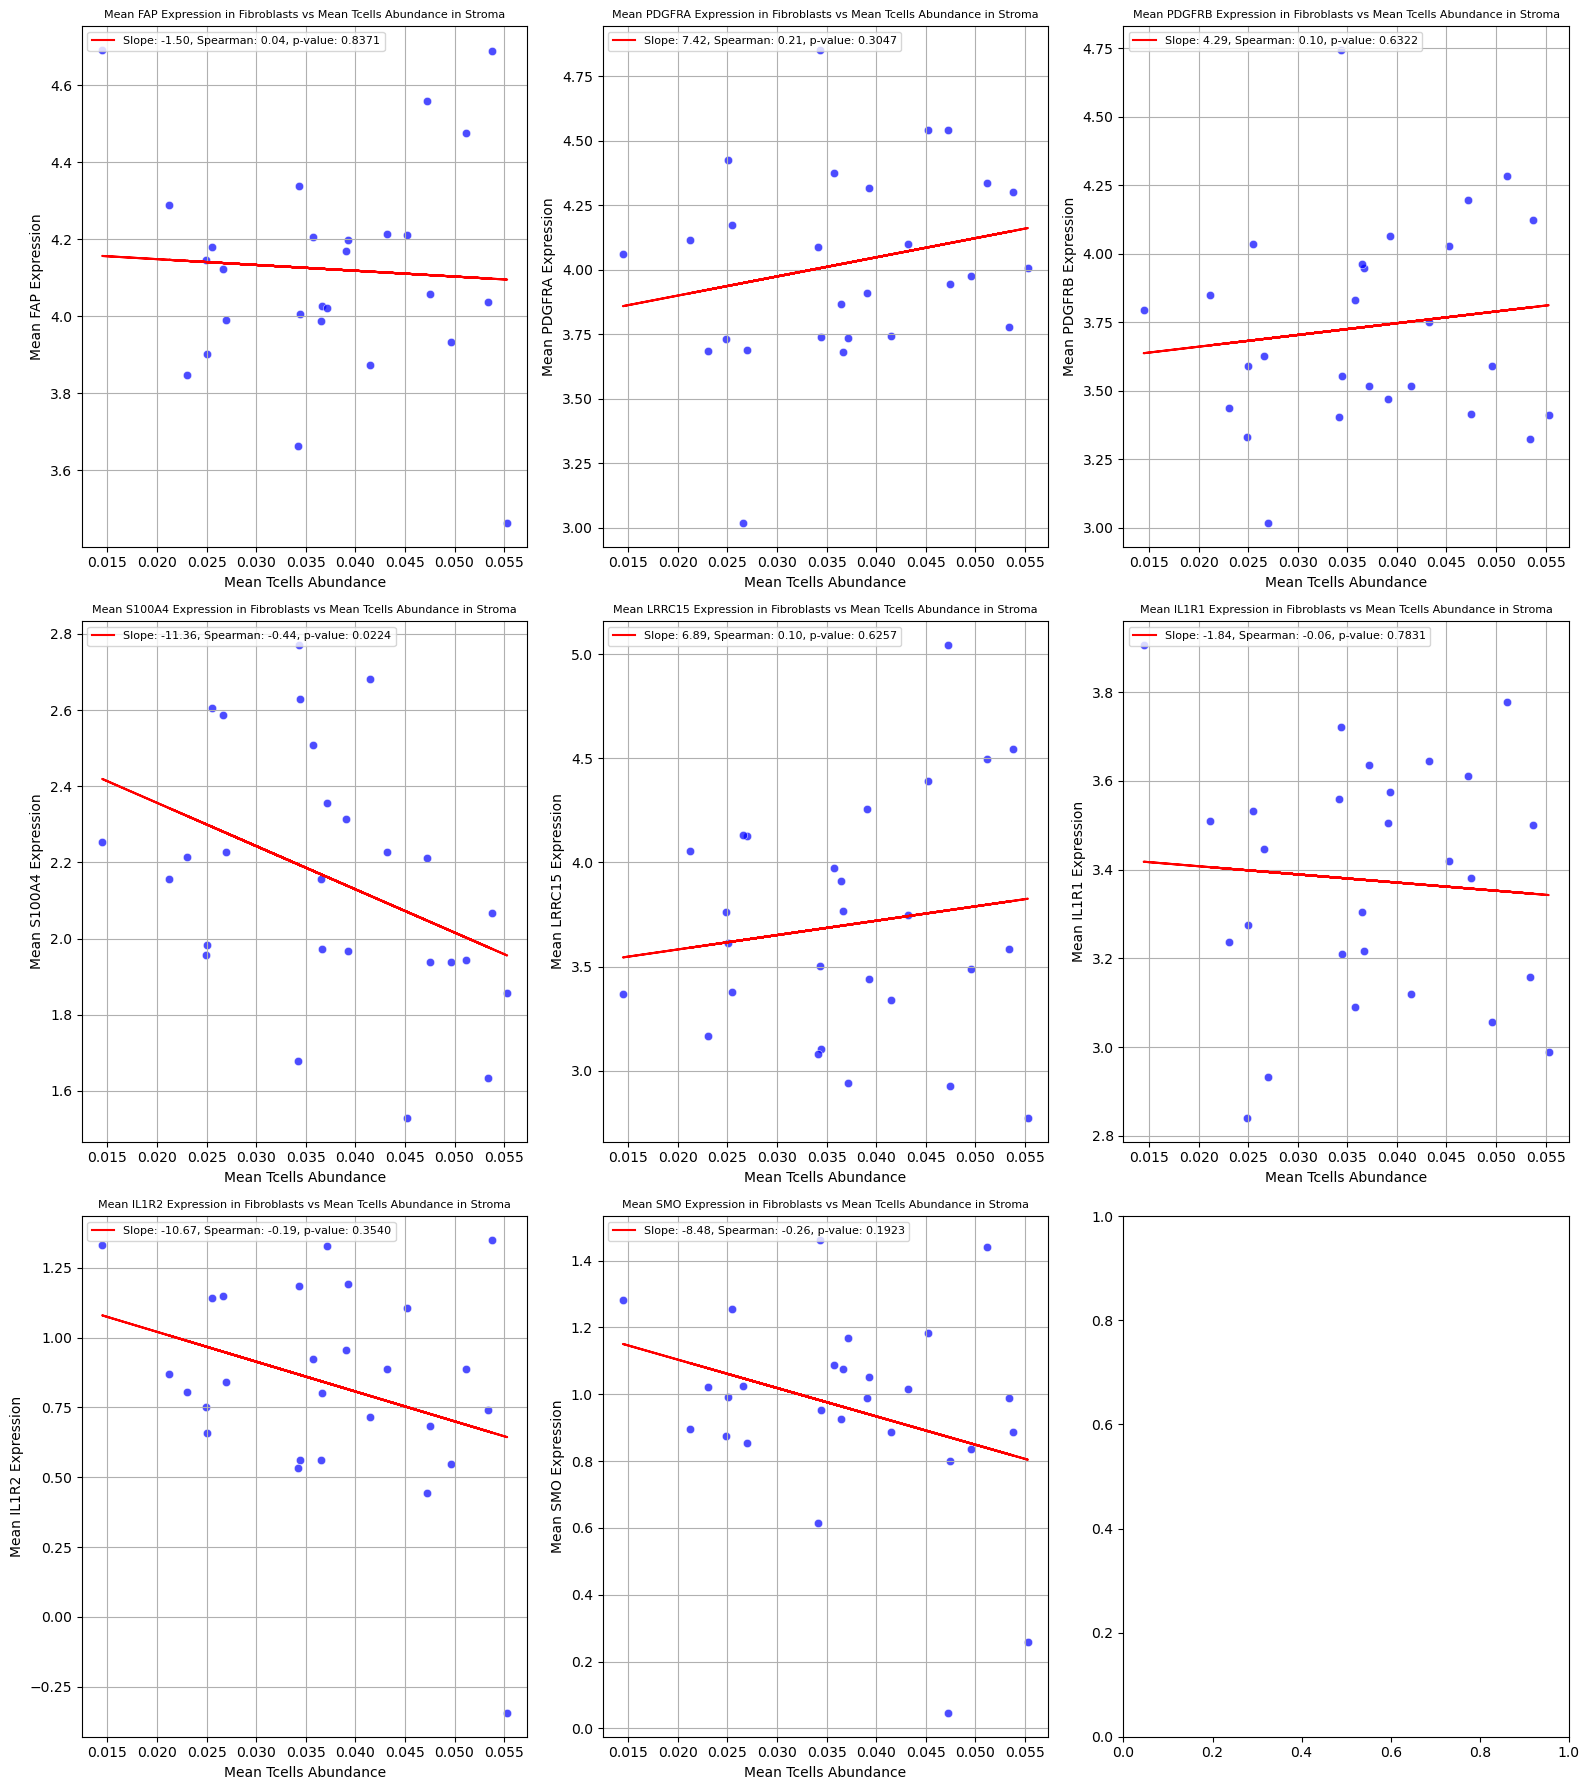

Spearman correlation for FAP vs Bcells: 0.03
Spearman correlation for PDGFRA vs Bcells: -0.06
Spearman correlation for PDGFRB vs Bcells: 0.11
Spearman correlation for S100A4 vs Bcells: 0.19
Spearman correlation for LRRC15 vs Bcells: 0.05
Spearman correlation for IL1R1 vs Bcells: -0.15
Spearman correlation for IL1R2 vs Bcells: 0.07
Spearman correlation for SMO vs Bcells: 0.06


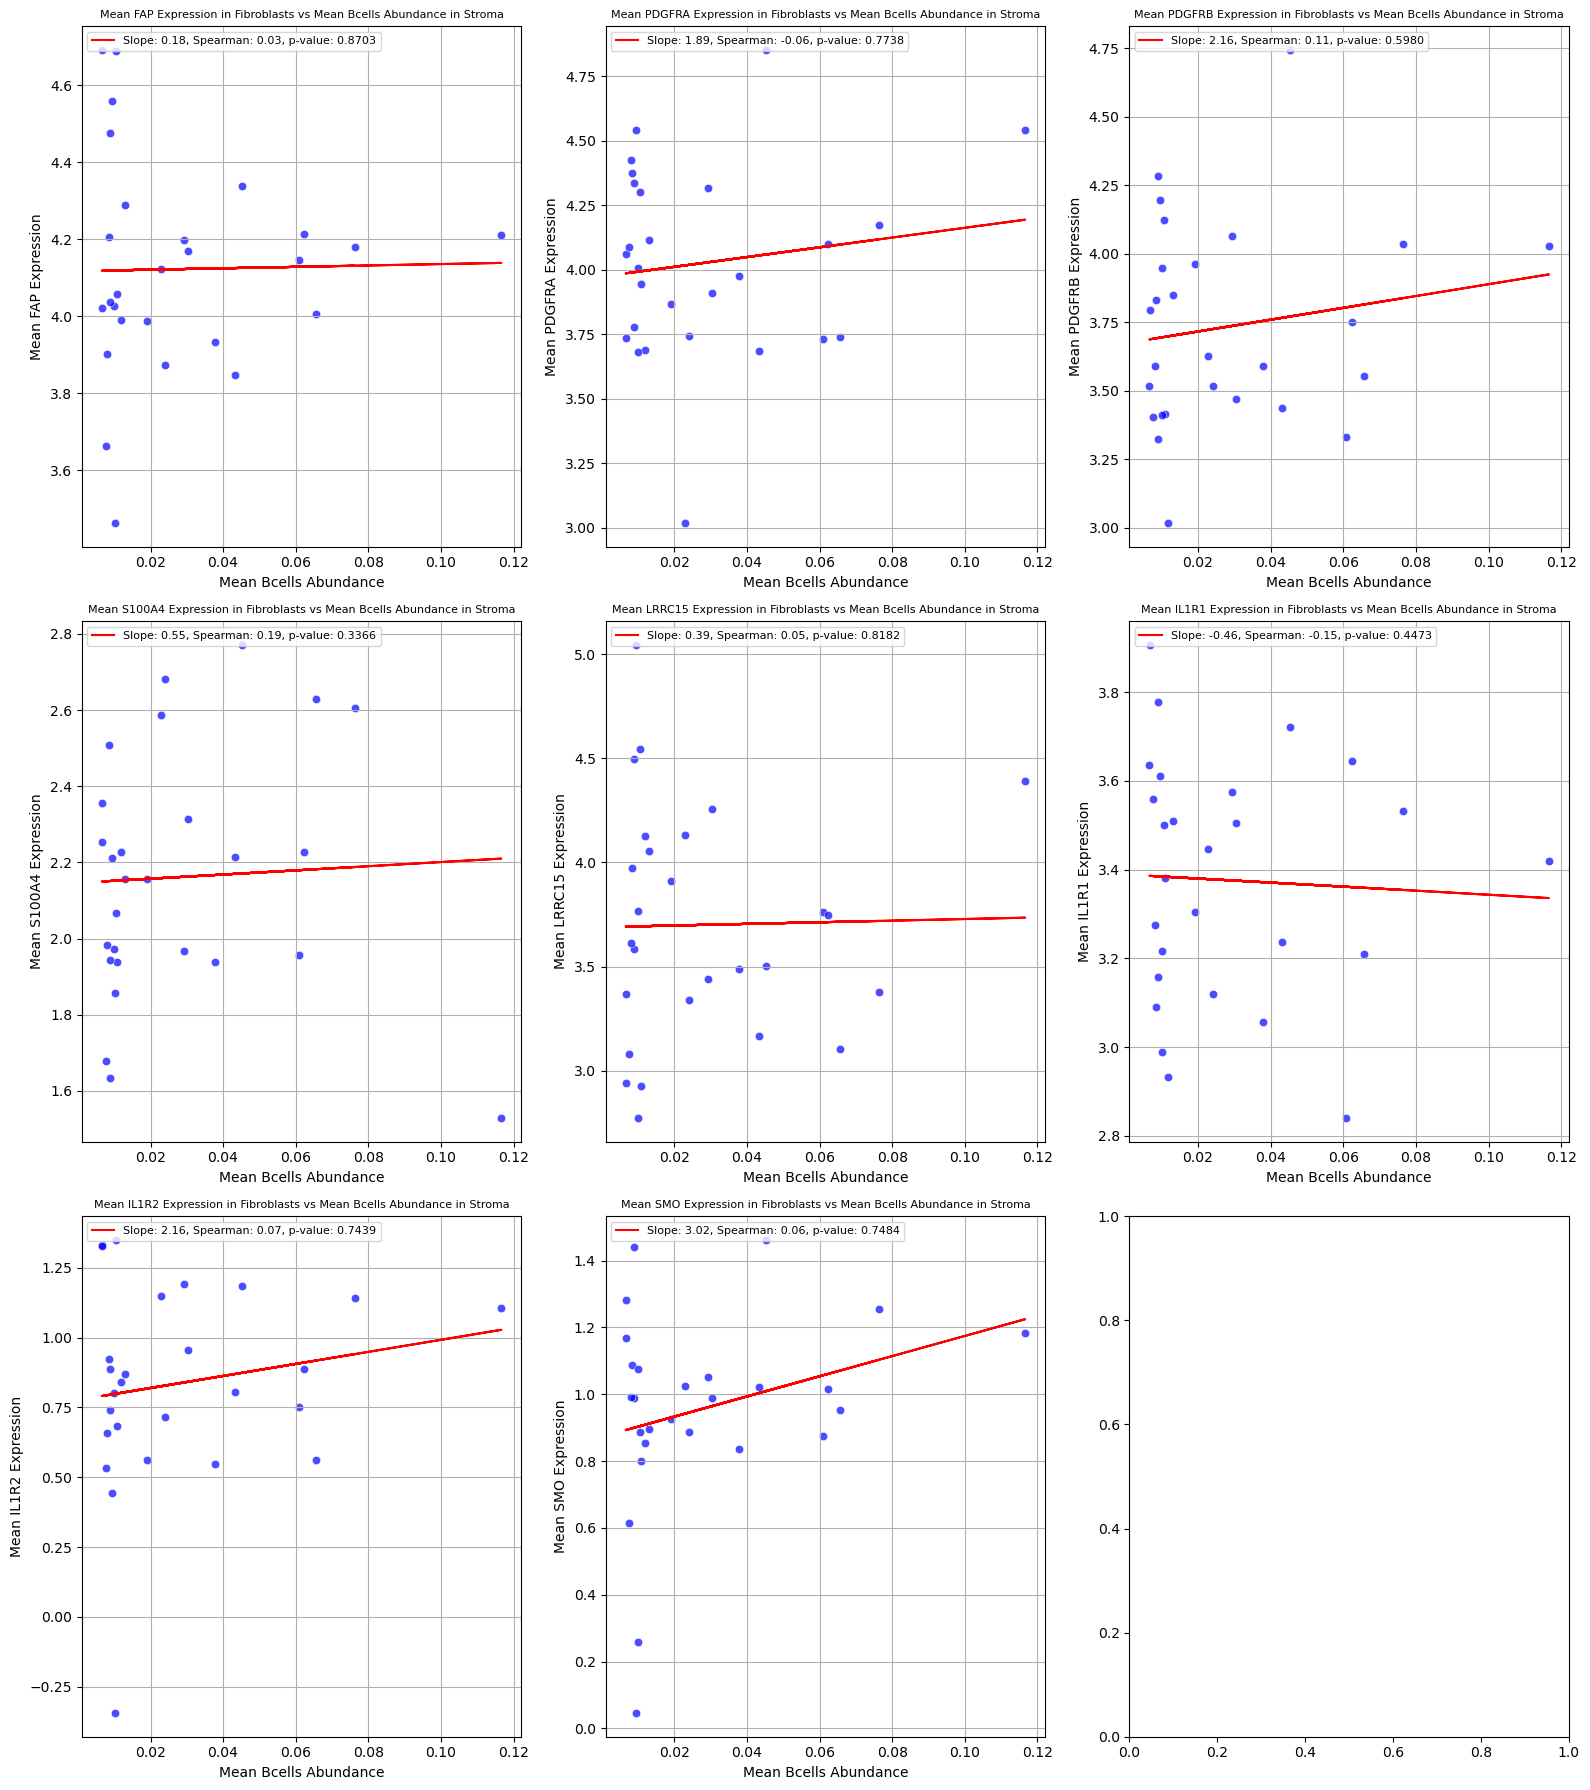

Spearman correlation for FAP vs NKcells: 0.40
Spearman correlation for PDGFRA vs NKcells: 0.52
Spearman correlation for PDGFRB vs NKcells: 0.50
Spearman correlation for S100A4 vs NKcells: 0.07
Spearman correlation for LRRC15 vs NKcells: 0.03
Spearman correlation for IL1R1 vs NKcells: 0.30
Spearman correlation for IL1R2 vs NKcells: 0.20
Spearman correlation for SMO vs NKcells: 0.23


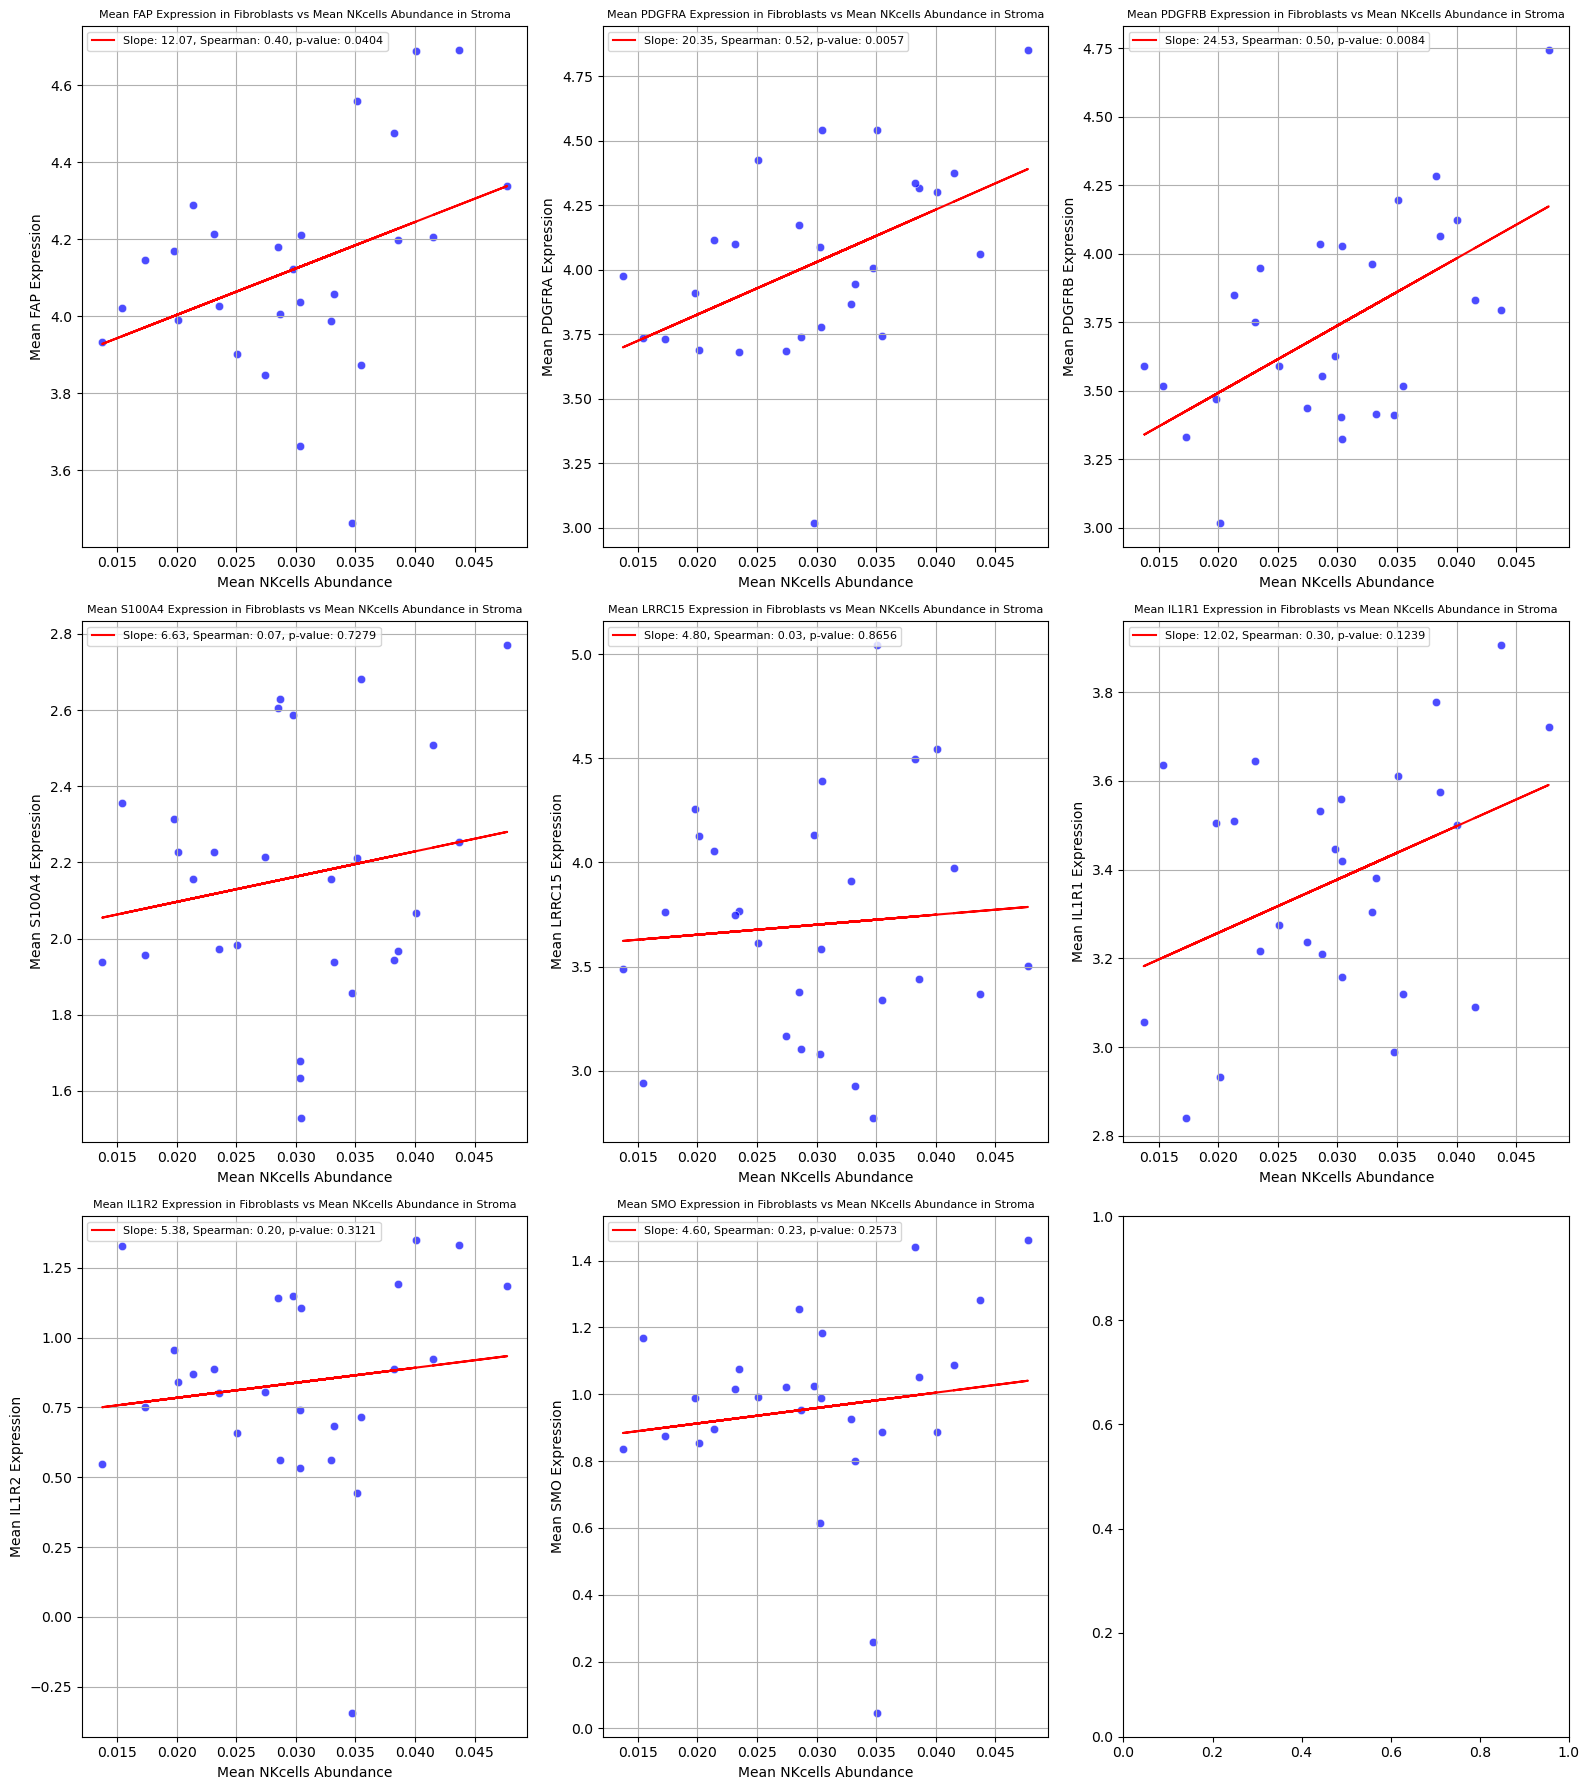

Spearman correlation for FAP vs Macrophages: -0.49
Spearman correlation for PDGFRA vs Macrophages: -0.30
Spearman correlation for PDGFRB vs Macrophages: -0.62
Spearman correlation for S100A4 vs Macrophages: -0.30
Spearman correlation for LRRC15 vs Macrophages: -0.30
Spearman correlation for IL1R1 vs Macrophages: -0.31
Spearman correlation for IL1R2 vs Macrophages: -0.35
Spearman correlation for SMO vs Macrophages: -0.31


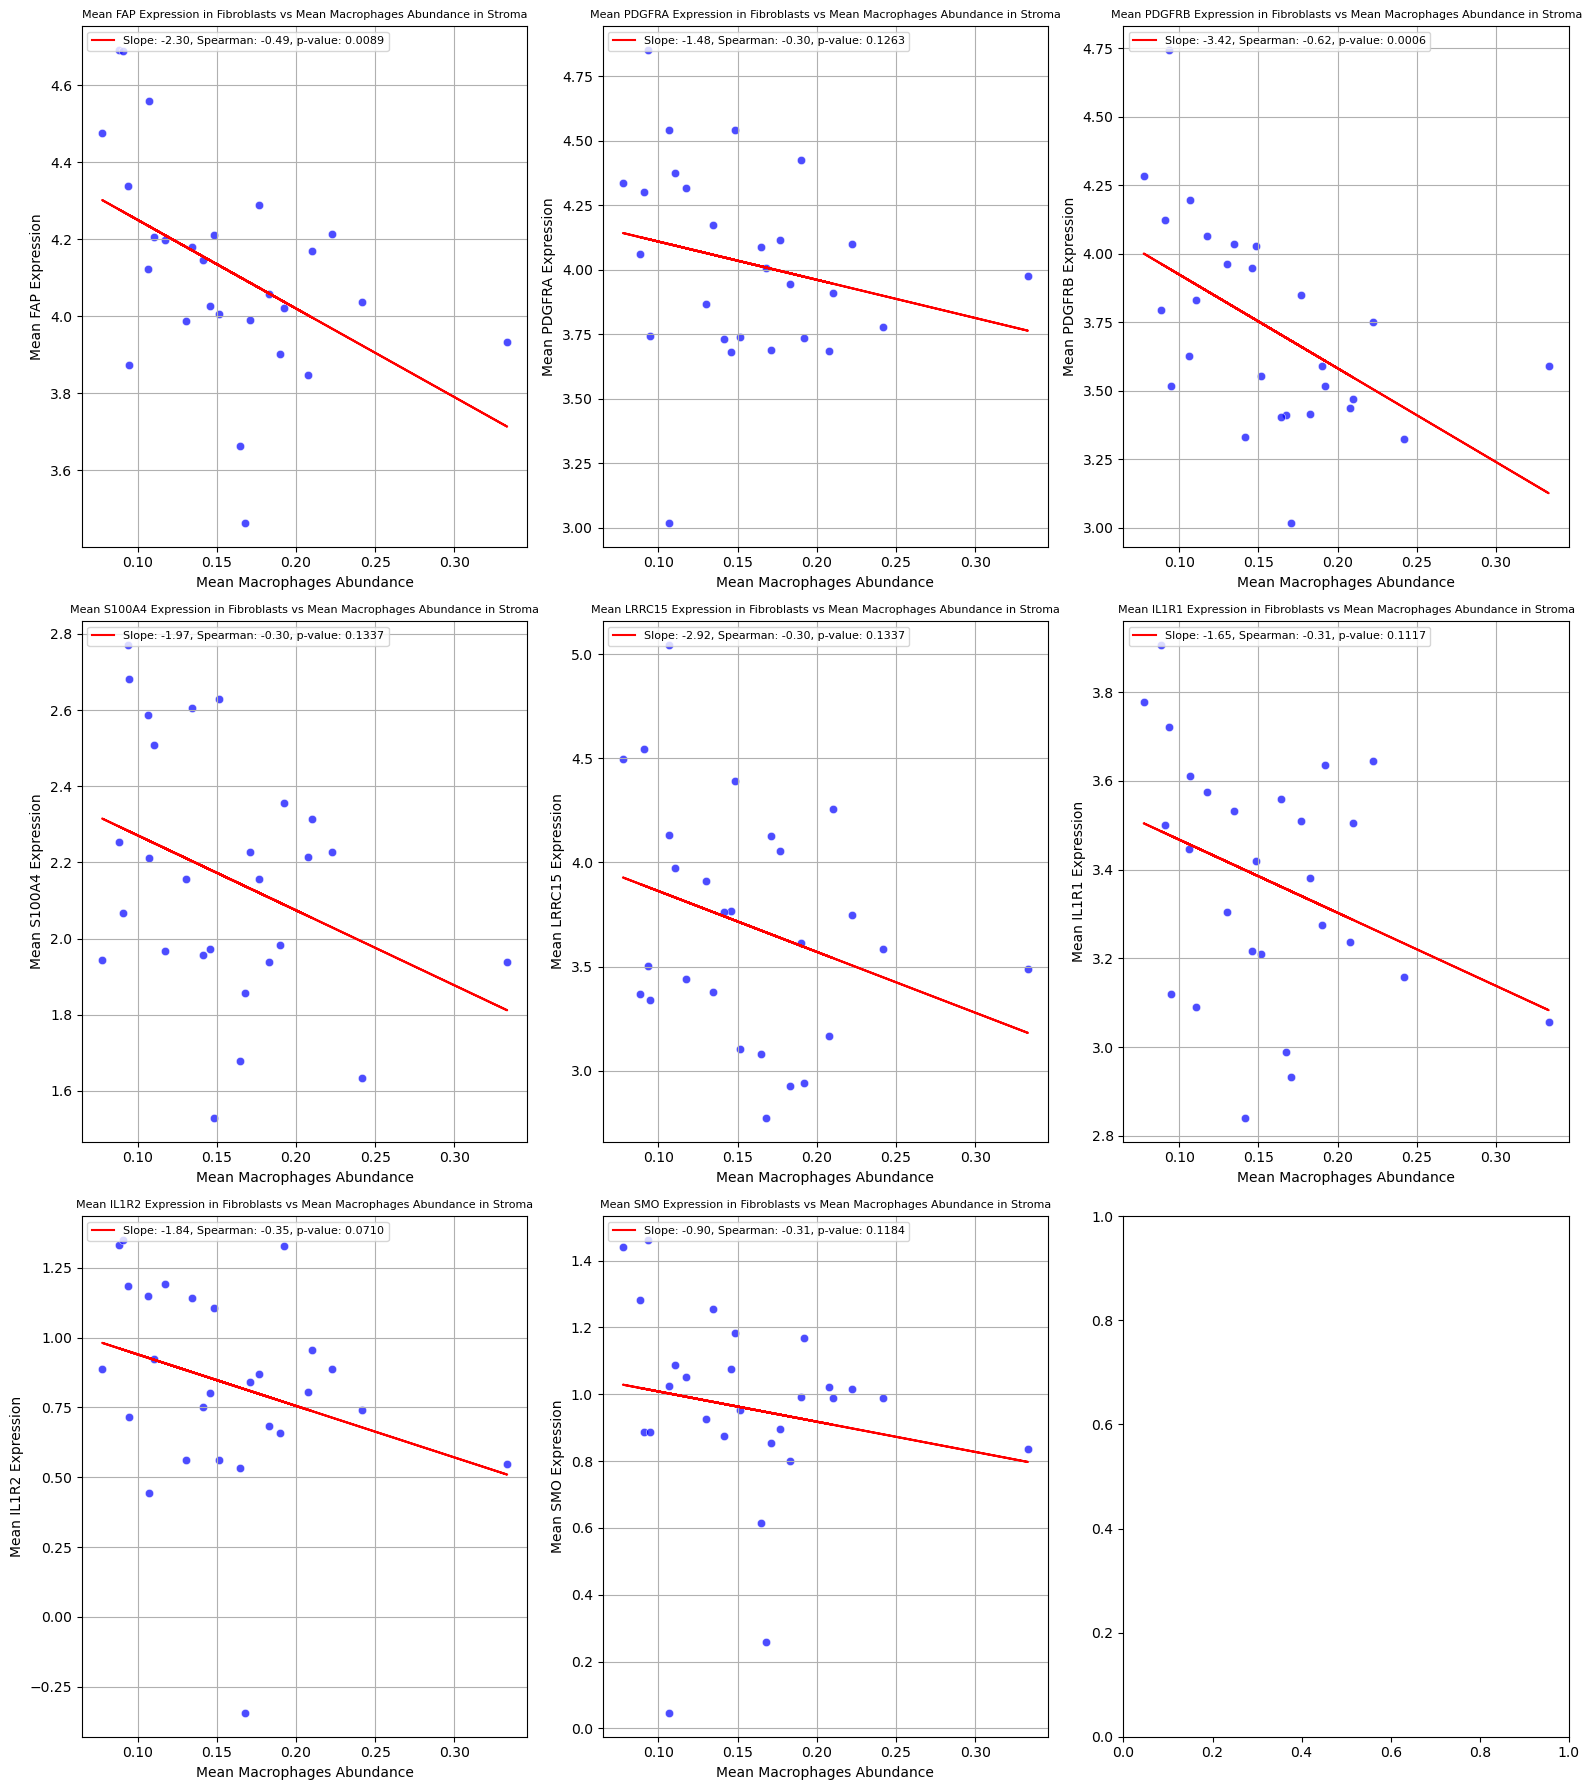

Spearman correlation for FAP vs Mast cells: nan
Spearman correlation for PDGFRA vs Mast cells: nan
Spearman correlation for PDGFRB vs Mast cells: nan
Spearman correlation for S100A4 vs Mast cells: nan
Spearman correlation for LRRC15 vs Mast cells: nan
Spearman correlation for IL1R1 vs Mast cells: nan
Spearman correlation for IL1R2 vs Mast cells: nan
Spearman correlation for SMO vs Mast cells: nan


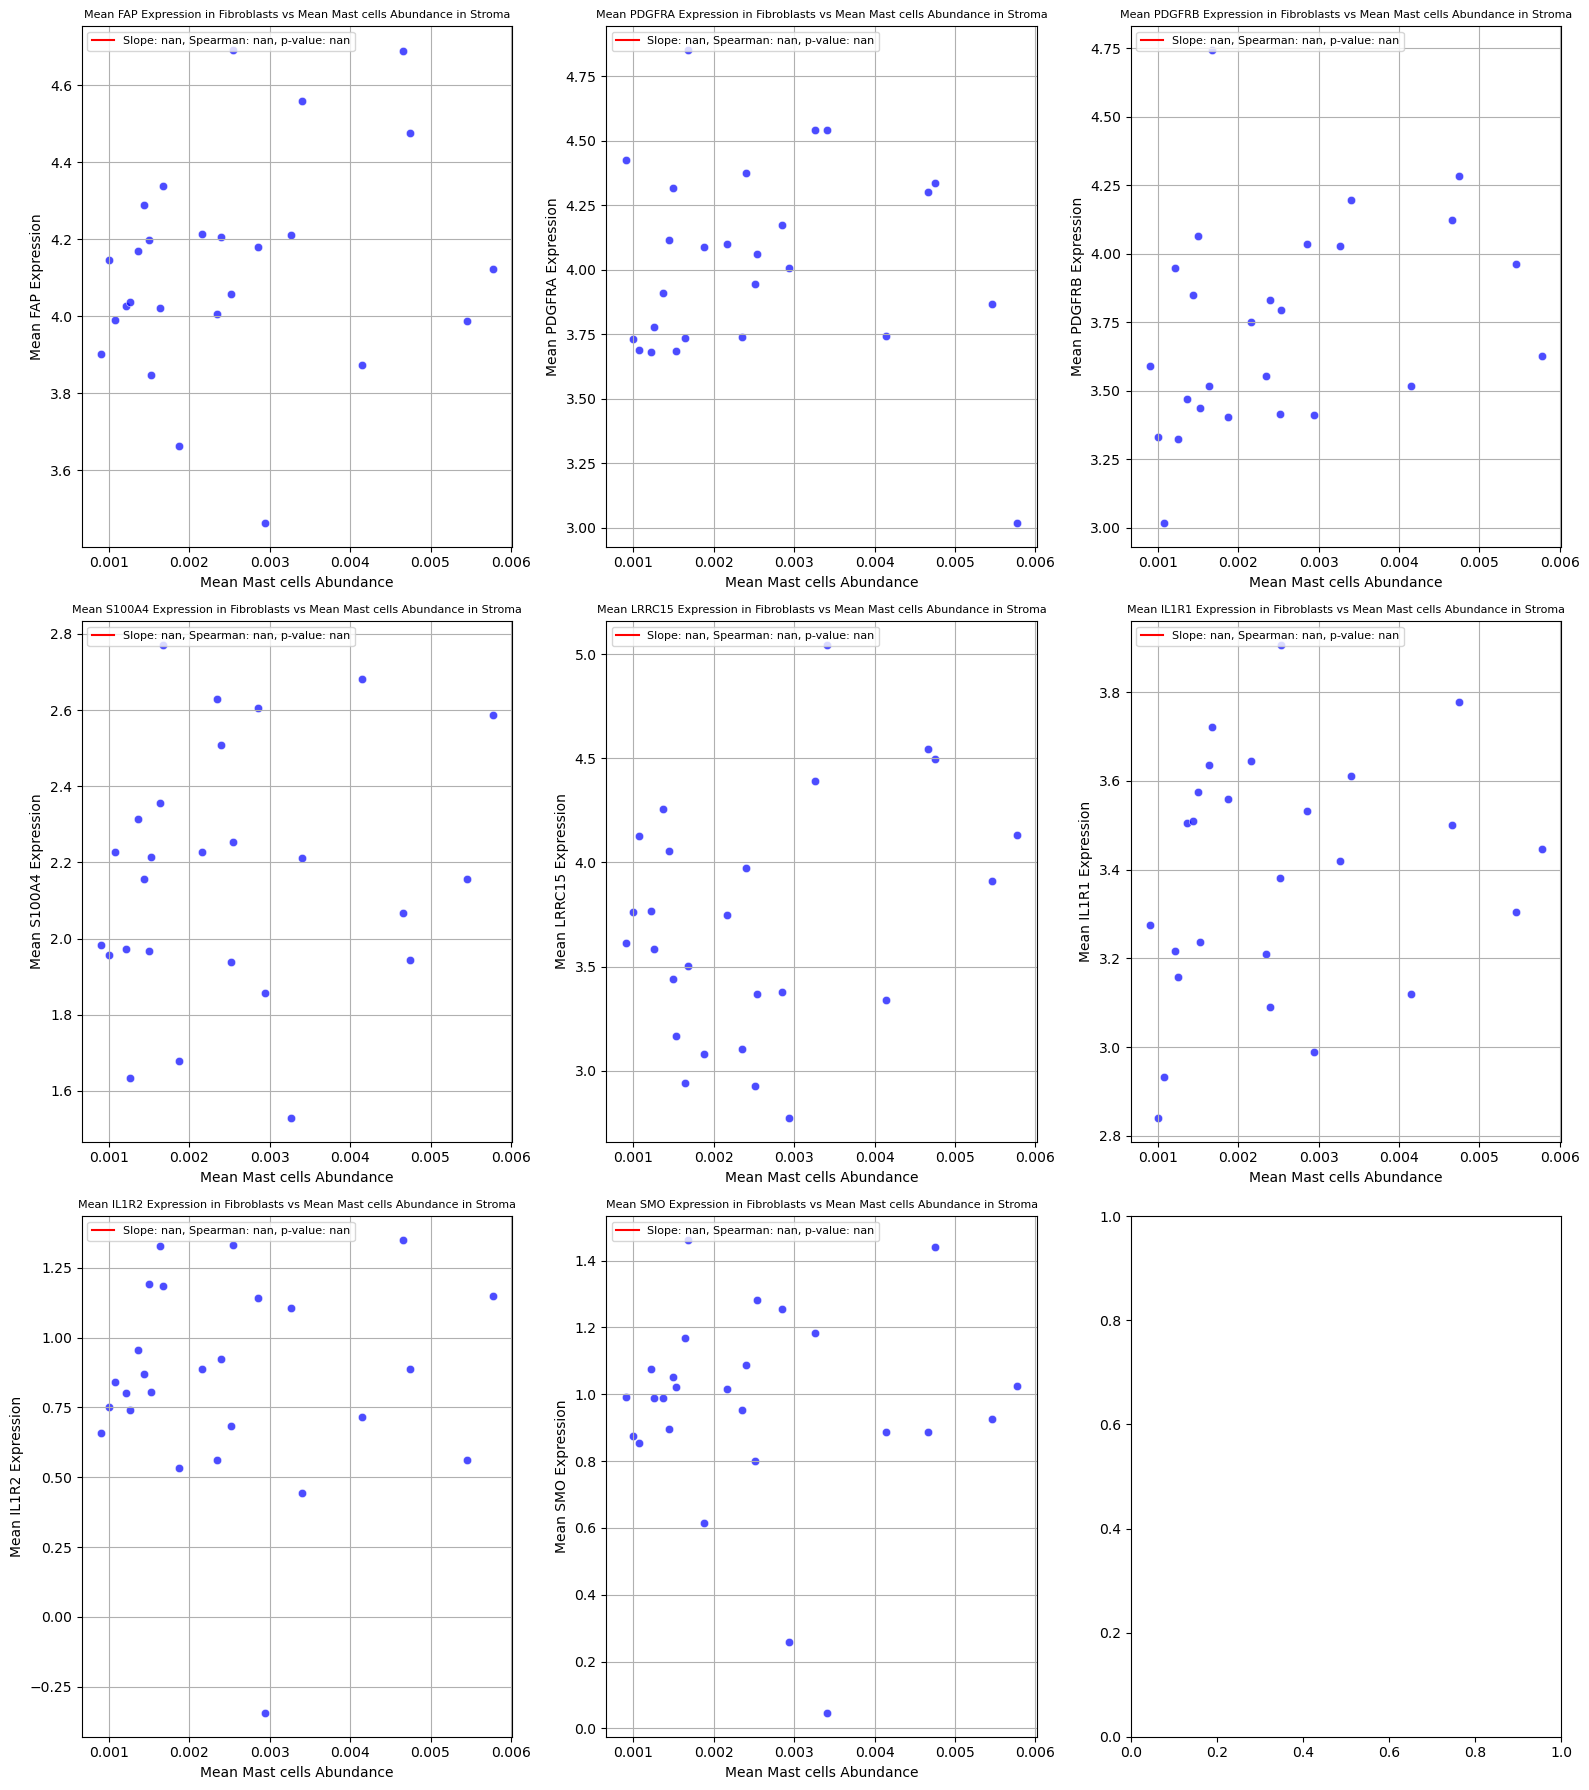

Spearman correlation for FAP vs DCs: 0.17
Spearman correlation for PDGFRA vs DCs: 0.15
Spearman correlation for PDGFRB vs DCs: 0.04
Spearman correlation for S100A4 vs DCs: -0.15
Spearman correlation for LRRC15 vs DCs: 0.04
Spearman correlation for IL1R1 vs DCs: 0.08
Spearman correlation for IL1R2 vs DCs: 0.03
Spearman correlation for SMO vs DCs: -0.11


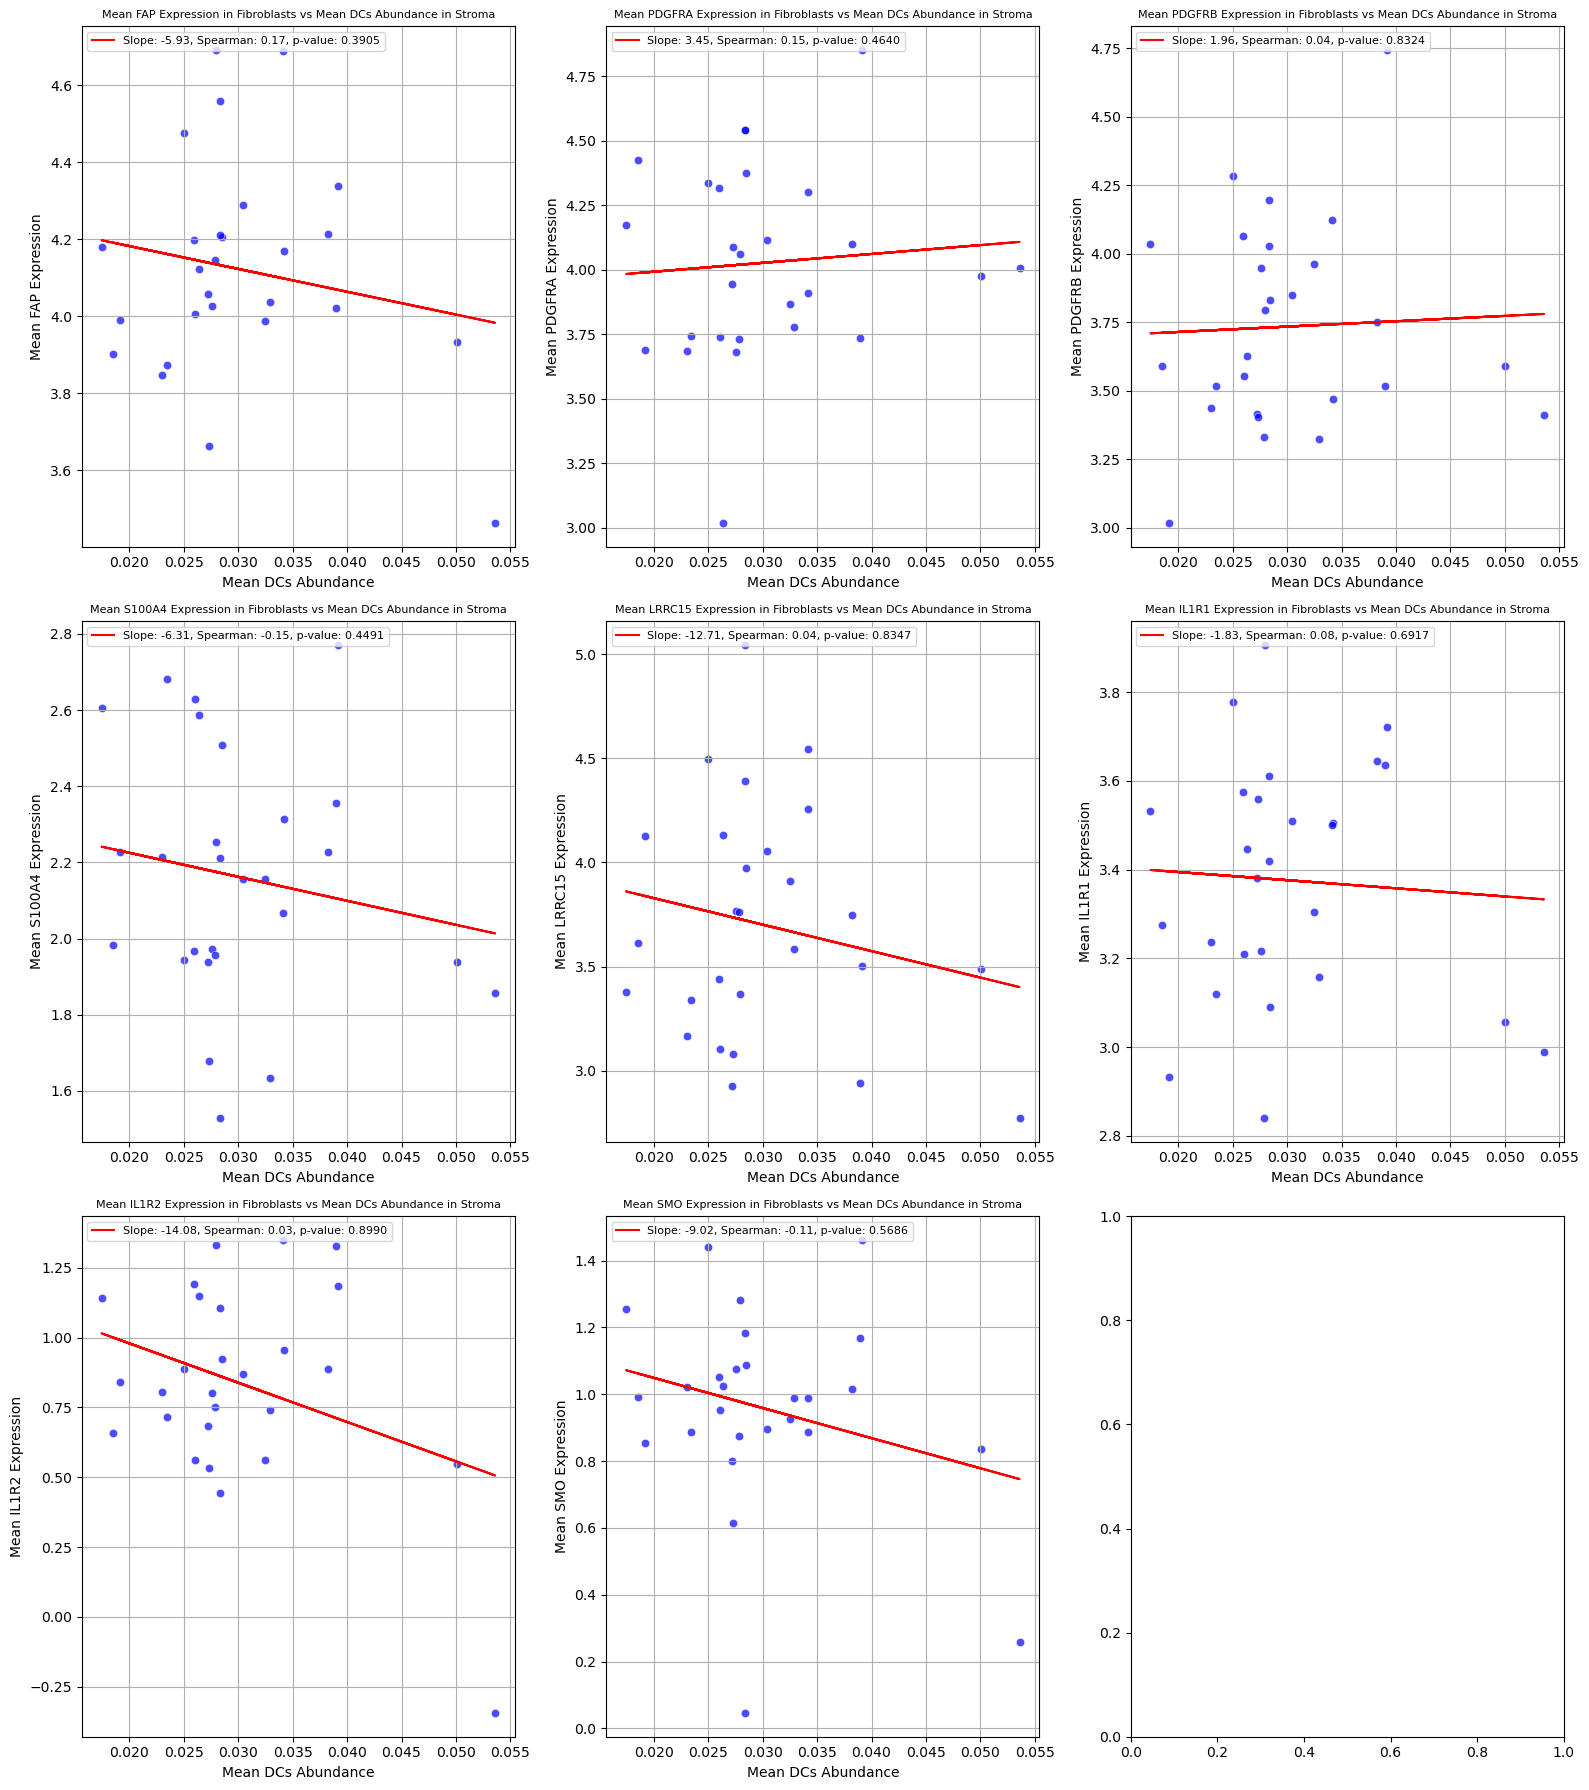

Spearman correlation for FAP vs other: nan
Spearman correlation for PDGFRA vs other: nan
Spearman correlation for PDGFRB vs other: nan
Spearman correlation for S100A4 vs other: nan
Spearman correlation for LRRC15 vs other: nan
Spearman correlation for IL1R1 vs other: nan
Spearman correlation for IL1R2 vs other: nan
Spearman correlation for SMO vs other: nan


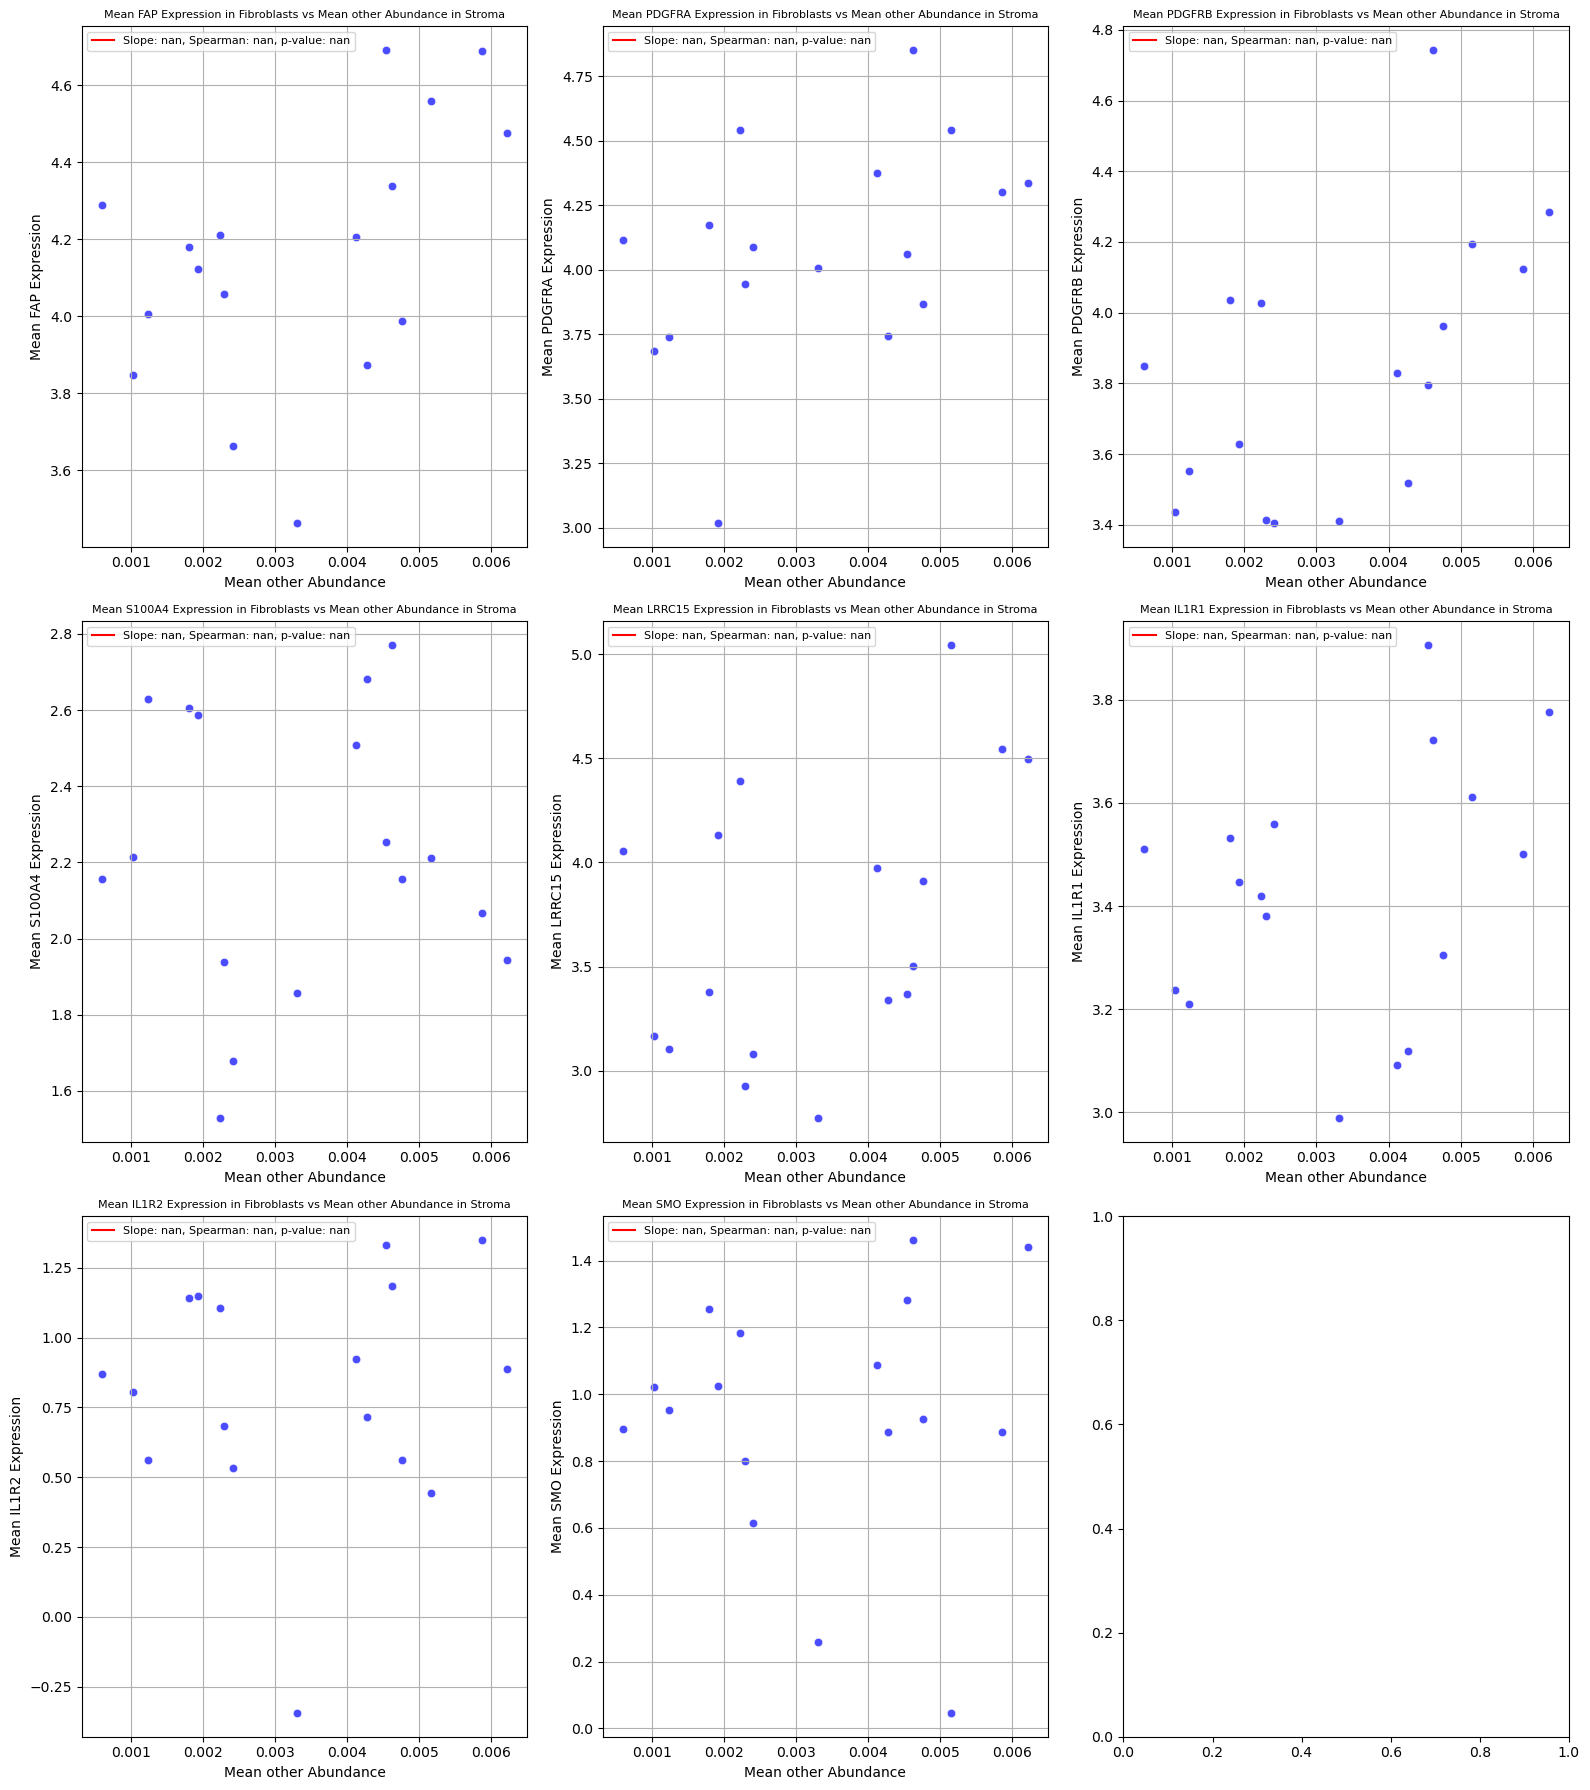

Spearman correlation for FAP vs Endothelial cells: -0.02
Spearman correlation for PDGFRA vs Endothelial cells: 0.33
Spearman correlation for PDGFRB vs Endothelial cells: 0.41
Spearman correlation for S100A4 vs Endothelial cells: -0.22
Spearman correlation for LRRC15 vs Endothelial cells: -0.05
Spearman correlation for IL1R1 vs Endothelial cells: 0.17
Spearman correlation for IL1R2 vs Endothelial cells: 0.05
Spearman correlation for SMO vs Endothelial cells: 0.15


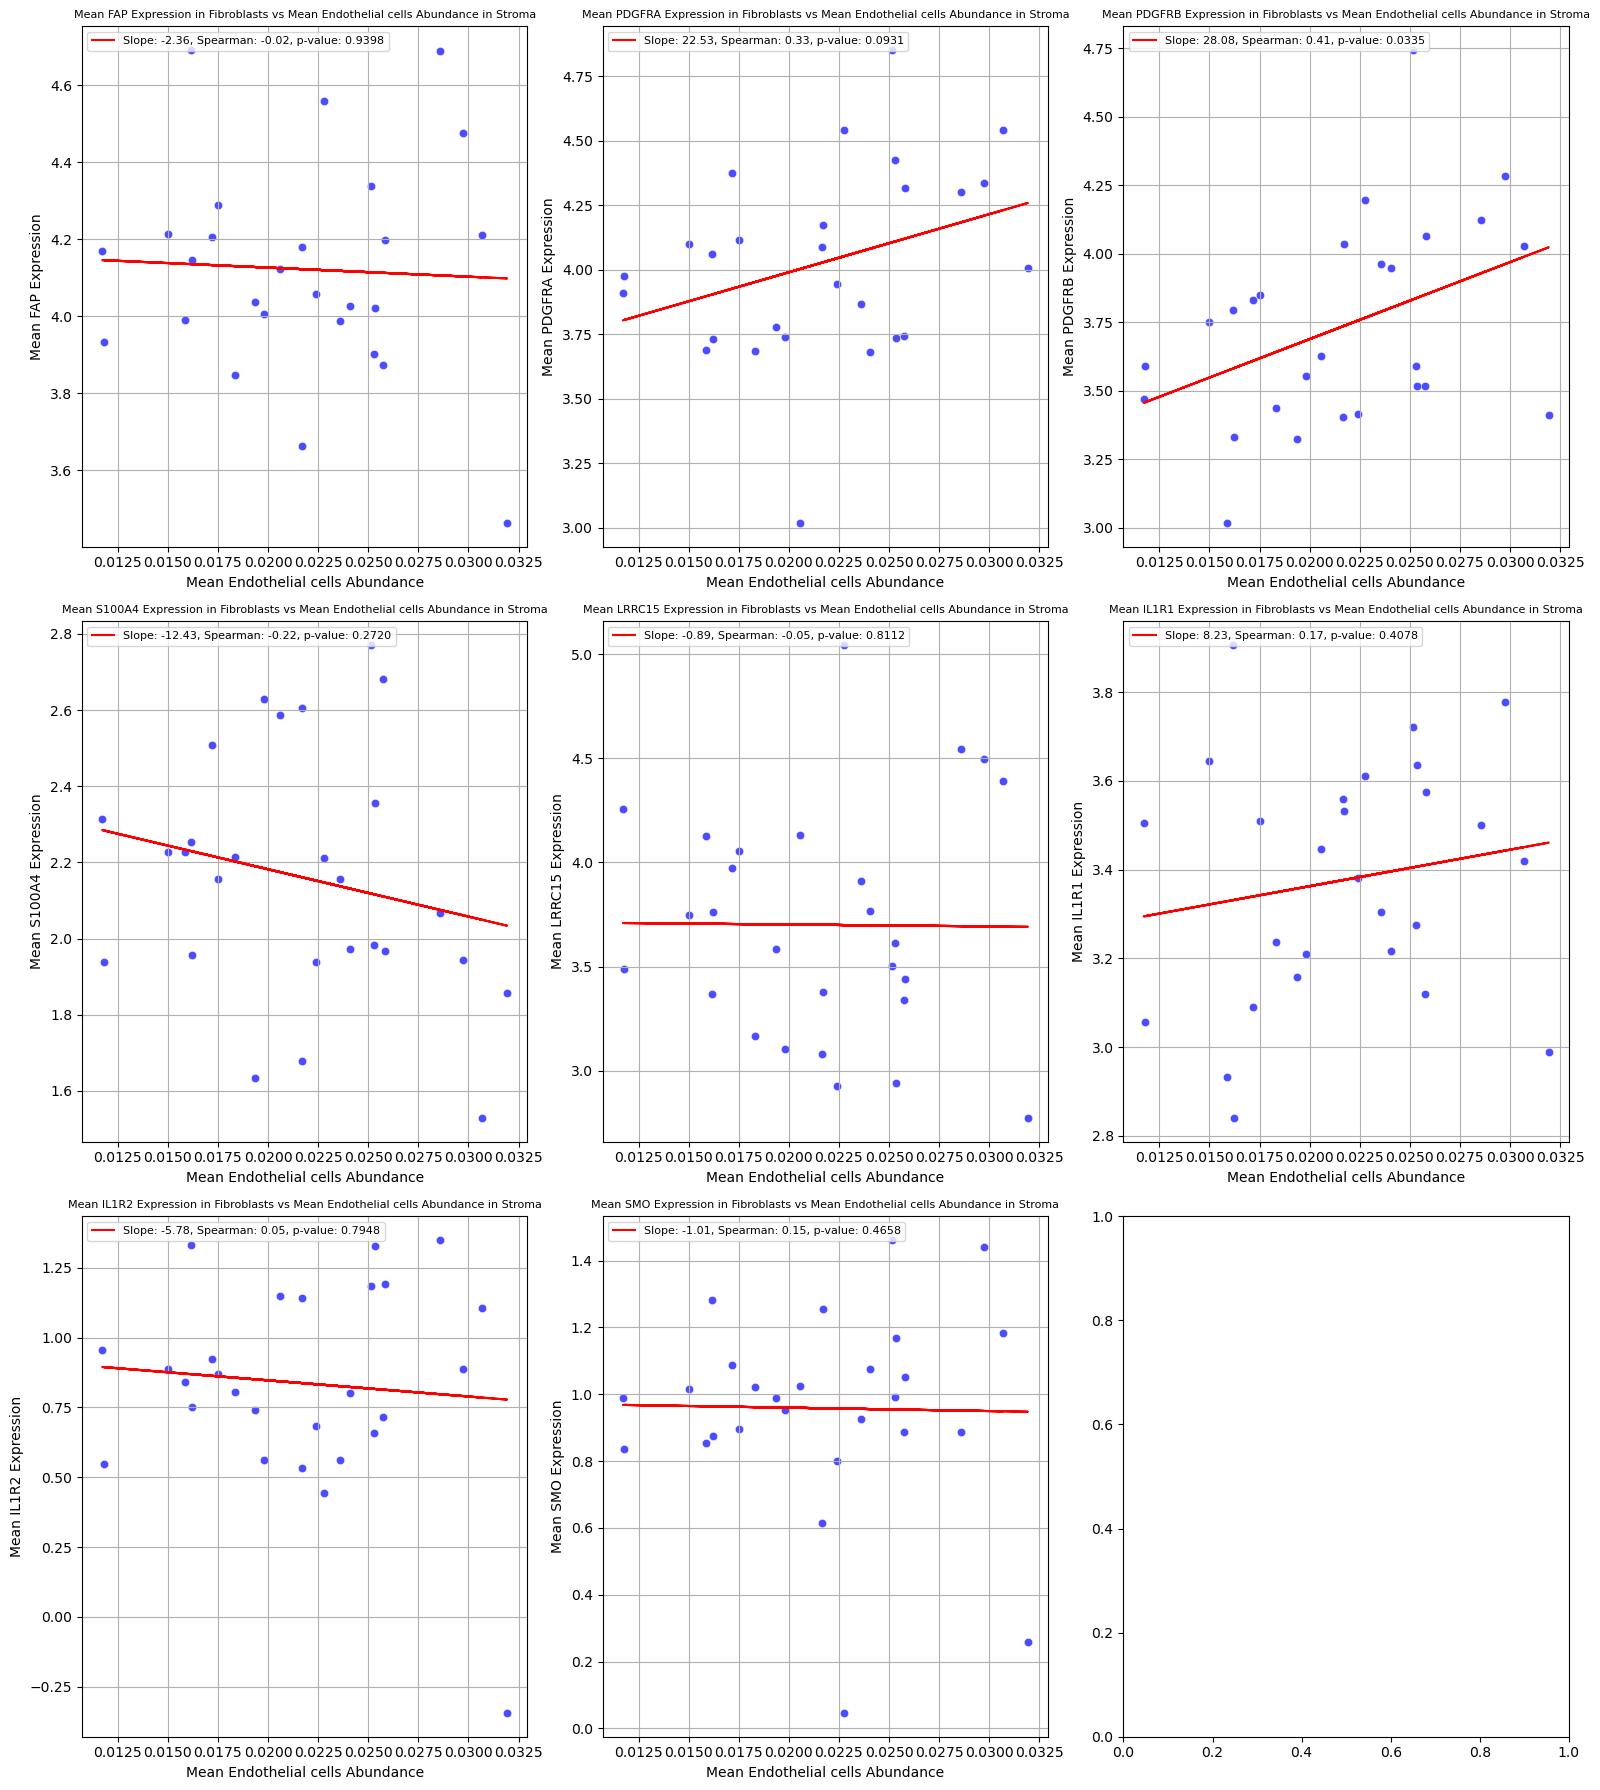

In [39]:
from scipy.stats import spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Set up the number of columns (3 plots per row)
ncols = 3

# Loop over each cell type to create individual plots
for cell in cell_types:
    # Determine the number of genes to plot for the current cell type
    num_genes = len(target_CAFs)

    # Set up the figure with subplots (3 columns, dynamic rows)
    nrows = (num_genes + ncols - 1) // ncols  # This ensures enough rows for all plots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 6))

    # Flatten axes array to easily index if there are multiple rows and columns
    axes = axes.flatten()

    for i, gene in enumerate(target_CAFs):
        # Create a scatter plot for each gene vs. cell type
        sns.scatterplot(data=average_stroma_cell_abundance, x=cell, y=gene, color='blue', alpha=0.7, ax=axes[i])

        # Spearman correlation
        spearman_corr, pvalue = spearmanr(average_stroma_cell_abundance[cell], average_stroma_cell_abundance[gene])
        kendall_corr, _ = kendalltau(average_stroma_cell_abundance[cell], average_stroma_cell_abundance[gene])
        print(f"Spearman correlation for {gene} vs {cell}: {spearman_corr:.2f}")

        # Linear regression
        slope, intercept, _, _, _ = linregress(average_stroma_cell_abundance[cell], average_stroma_cell_abundance[gene])
        regression_line = slope * average_stroma_cell_abundance[cell] + intercept
        axes[i].plot(average_stroma_cell_abundance[cell], regression_line, label=f'Slope: {slope:.2f}, Spearman: {spearman_corr:.2f}, p-value: {pvalue:.4f}', color='red')

        # Plot formatting
        axes[i].set_title(f"Mean {gene} Expression in Fibroblasts vs Mean {cell} Abundance in Stroma",fontsize=8)
        axes[i].set_xlabel(f"Mean {cell} Abundance")
        axes[i].set_ylabel(f"Mean {gene} Expression")
        axes[i].grid()

        # Add legend for each plot
        axes[i].legend(loc='upper left', fontsize=8)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the figure for the current cell type
    plt.show()


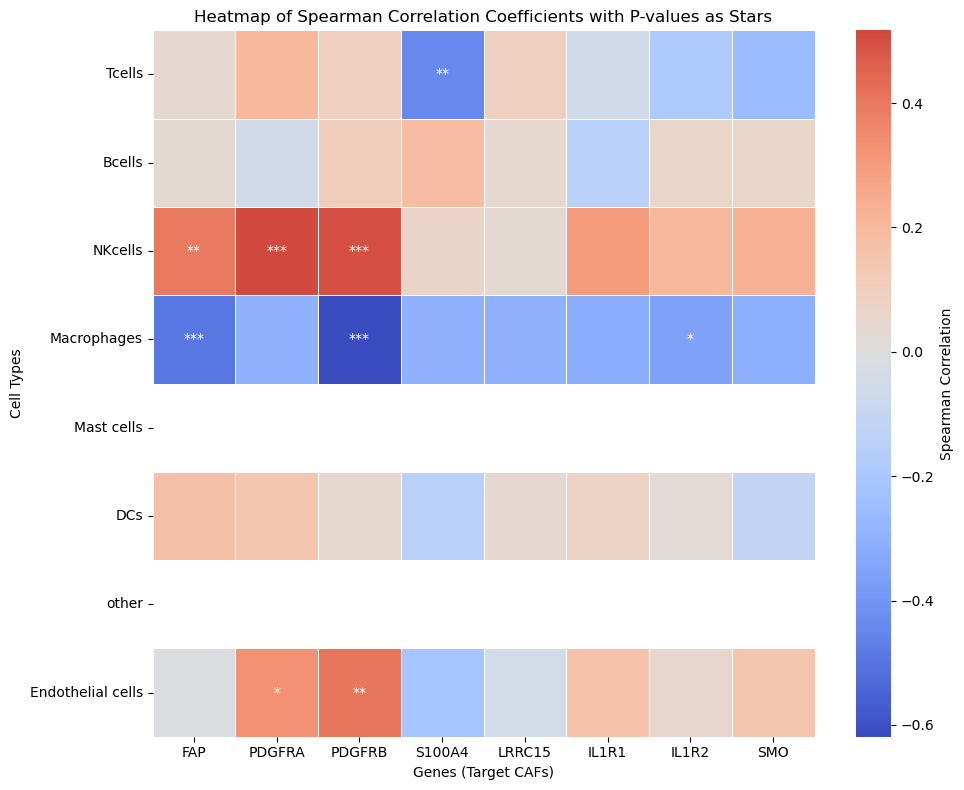

In [40]:
correlation_matrix = []
p_value_matrix = []

# Loop over cell types and target genes to compute correlation coefficients and p-values
for cell in cell_types:
    corr_row = []
    p_value_row = []
    
    for gene in target_CAFs:
        # Calculate the Spearman correlation and p-value
        spearman_corr, p_value = spearmanr(average_stroma_cell_abundance[cell], average_stroma_cell_abundance[gene])

        # Append the correlation and p-value to the respective rows
        corr_row.append(spearman_corr)
        p_value_row.append(p_value)
    
    # Append each row of correlations and p-values to the matrices
    correlation_matrix.append(corr_row)
    p_value_matrix.append(p_value_row)

# Convert the correlation and p-value matrices to numpy arrays for easier manipulation
correlation_matrix = np.array(correlation_matrix)
p_value_matrix = np.array(p_value_matrix)

# Create a matrix of stars based on p-value thresholds
star_matrix = np.empty_like(p_value_matrix, dtype=object)
for i in range(p_value_matrix.shape[0]):
    for j in range(p_value_matrix.shape[1]):
        p_val = p_value_matrix[i, j]
        if p_val < 0.01:
            star_matrix[i, j] = "***"
        elif p_val < 0.05:
            star_matrix[i, j] = "**"
        elif p_val < 0.1:
            star_matrix[i, j] = "*"
        else:
            star_matrix[i, j] = ""

# Create a heatmap for the correlation coefficients
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=star_matrix, fmt='', cmap='coolwarm', center=0, 
            xticklabels=target_CAFs, yticklabels=cell_types, annot_kws={'size': 10}, 
            cbar_kws={'label': 'Spearman Correlation'}, linewidths=0.5)

# Customize the plot
plt.title("Heatmap of Spearman Correlation Coefficients with P-values as Stars")
plt.xlabel("Genes (Target CAFs)")
plt.ylabel("Cell Types")
plt.tight_layout()
plt.show()

Spearman correlation for FAP vs Tcells: 0.04
Spearman correlation for PDGFRA vs Tcells: 0.21
Spearman correlation for PDGFRB vs Tcells: 0.10
Spearman correlation for S100A4 vs Tcells: -0.44
Spearman correlation for LRRC15 vs Tcells: 0.10
Spearman correlation for IL1R1 vs Tcells: -0.06
Spearman correlation for IL1R2 vs Tcells: -0.19
Spearman correlation for SMO vs Tcells: -0.26


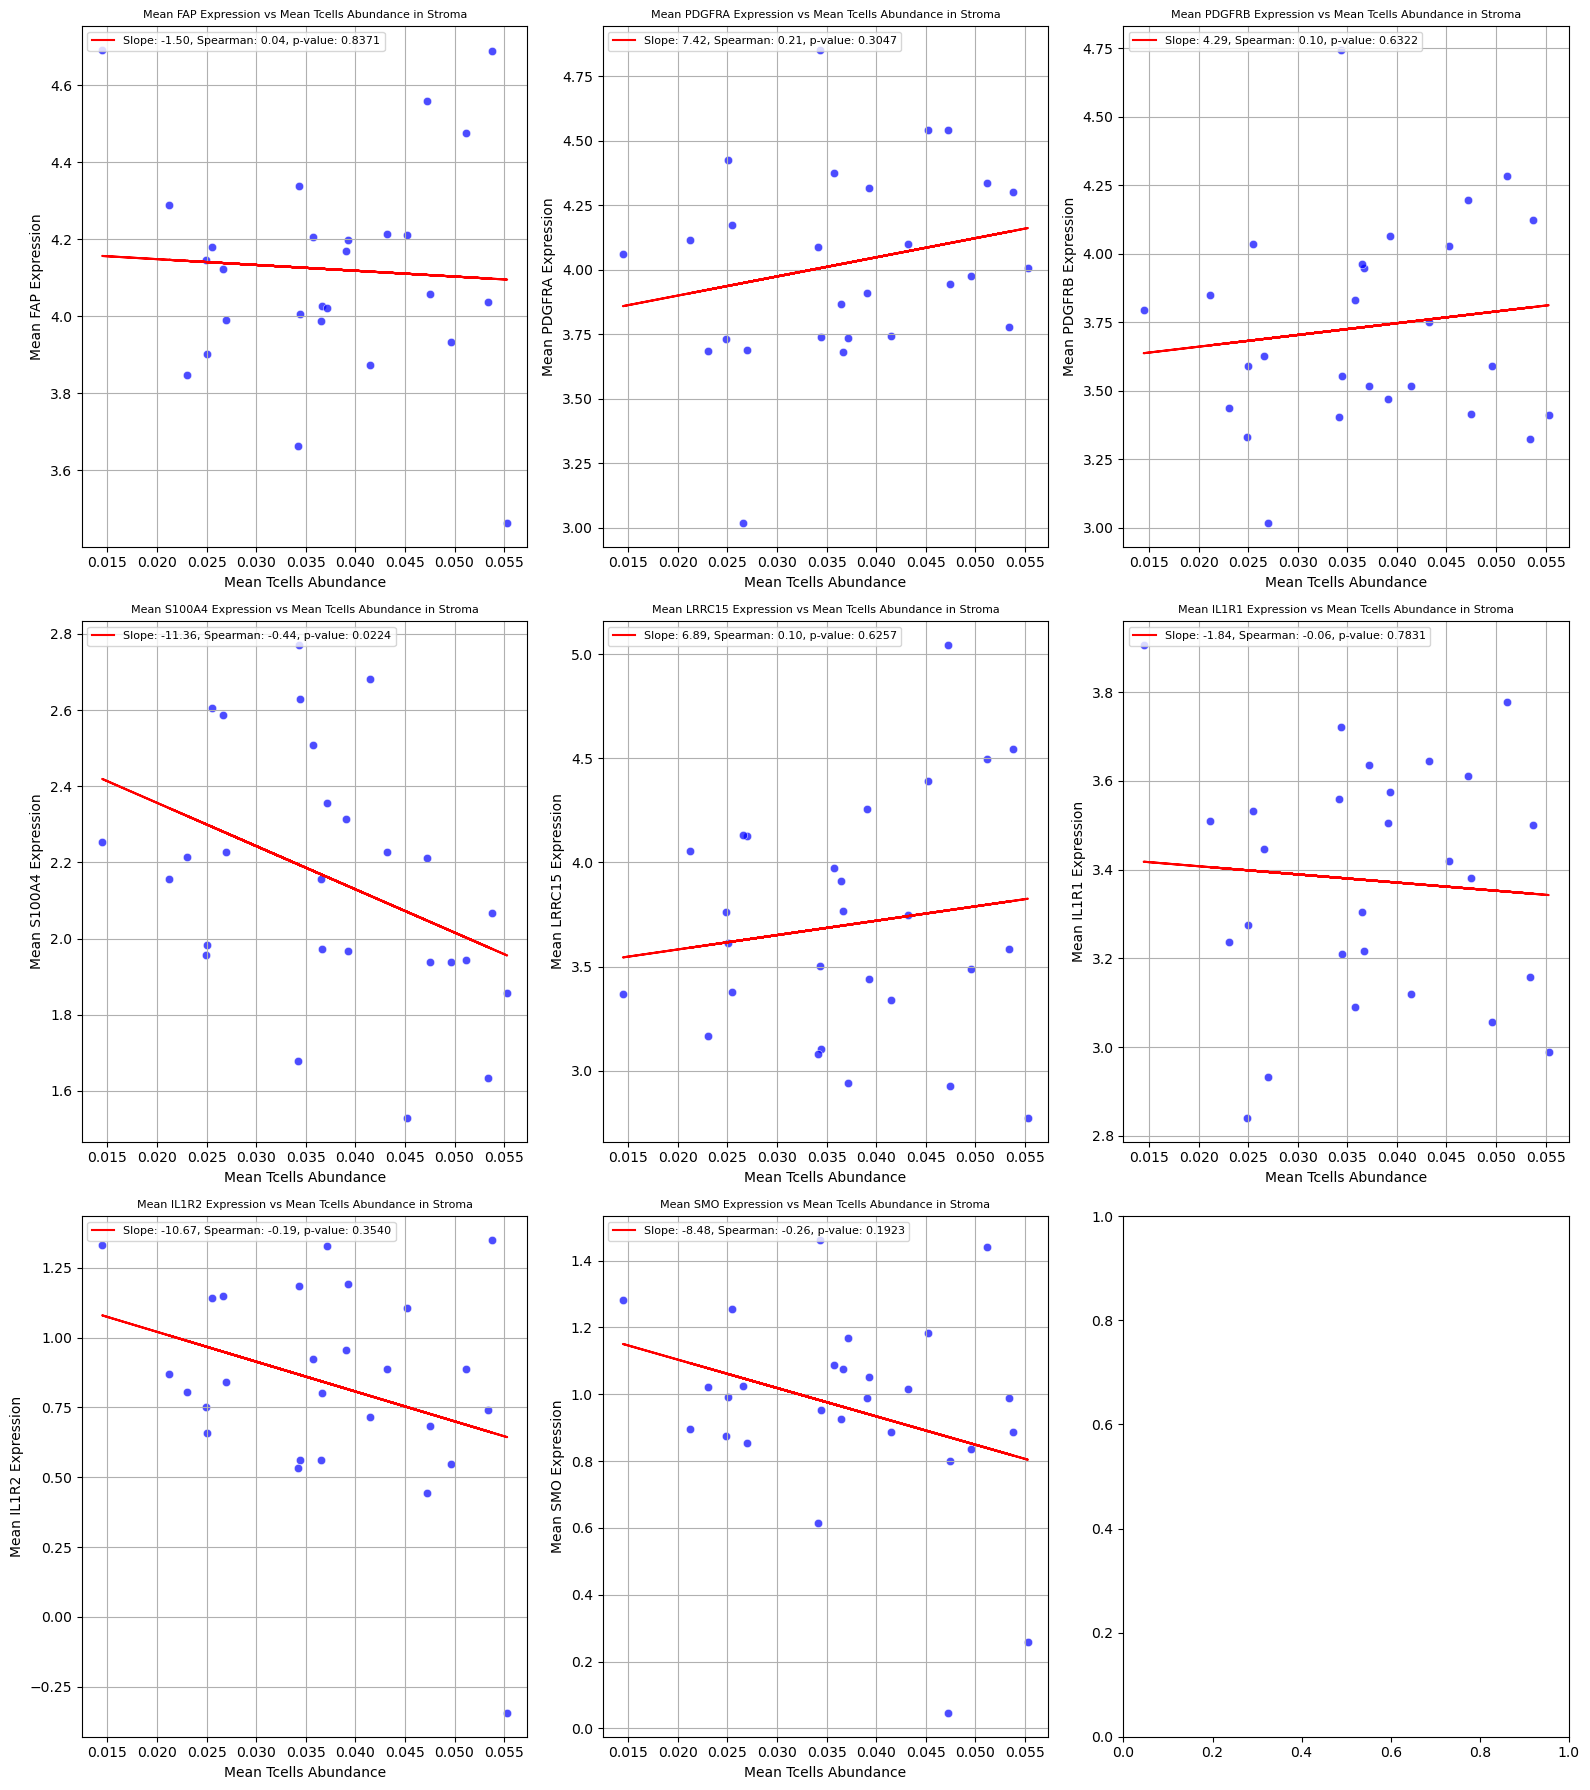

Spearman correlation for FAP vs Bcells: 0.03
Spearman correlation for PDGFRA vs Bcells: -0.06
Spearman correlation for PDGFRB vs Bcells: 0.11
Spearman correlation for S100A4 vs Bcells: 0.19
Spearman correlation for LRRC15 vs Bcells: 0.05
Spearman correlation for IL1R1 vs Bcells: -0.15
Spearman correlation for IL1R2 vs Bcells: 0.07
Spearman correlation for SMO vs Bcells: 0.06


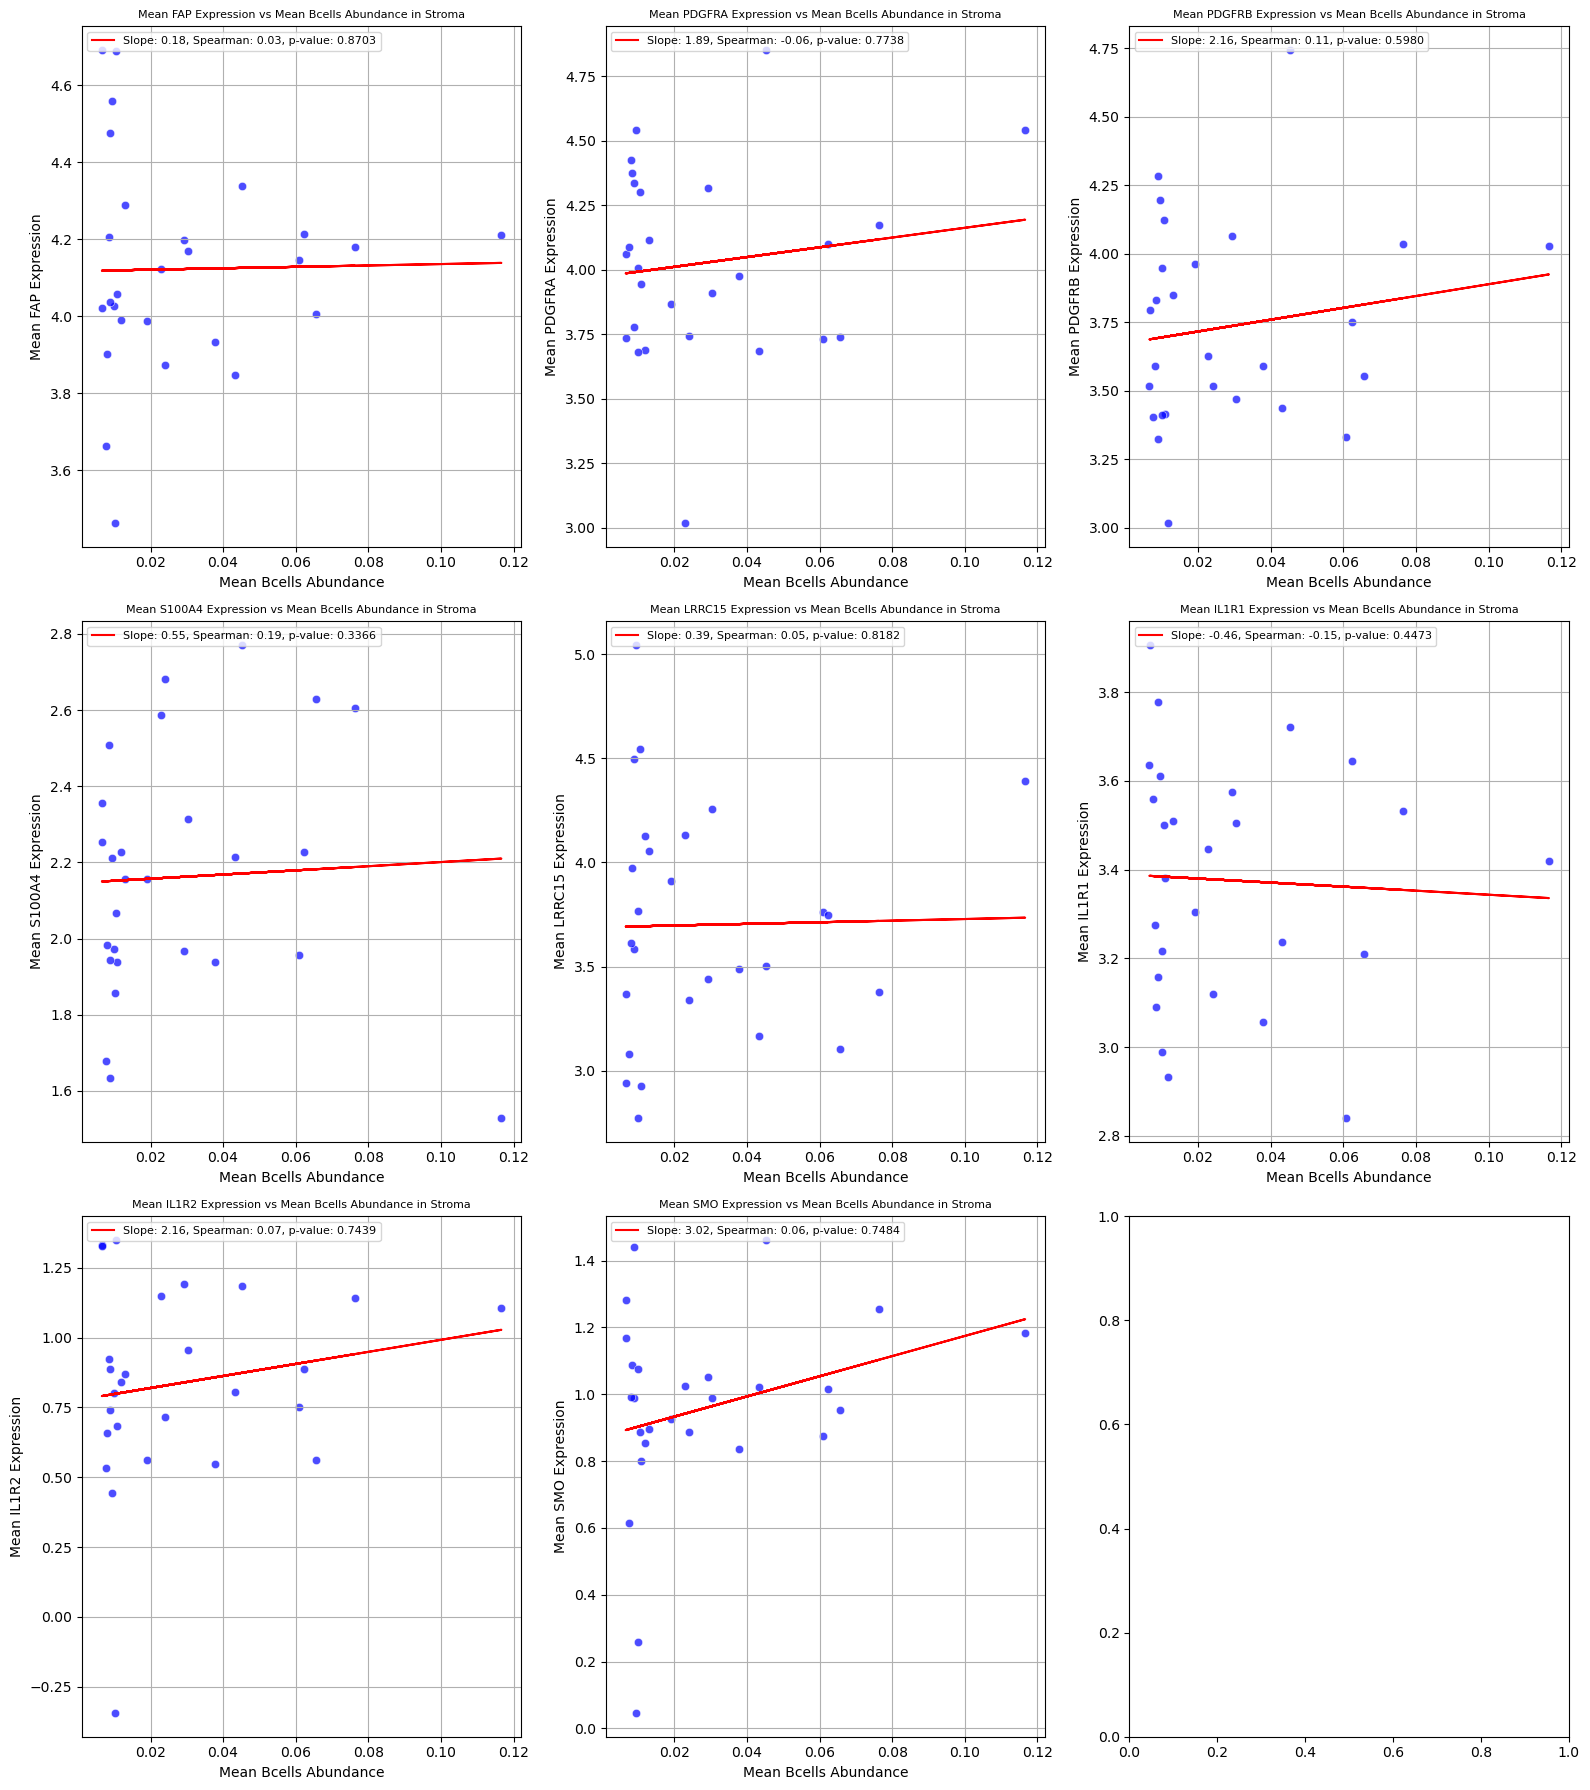

Spearman correlation for FAP vs NKcells: 0.40
Spearman correlation for PDGFRA vs NKcells: 0.52
Spearman correlation for PDGFRB vs NKcells: 0.50
Spearman correlation for S100A4 vs NKcells: 0.07
Spearman correlation for LRRC15 vs NKcells: 0.03
Spearman correlation for IL1R1 vs NKcells: 0.30
Spearman correlation for IL1R2 vs NKcells: 0.20
Spearman correlation for SMO vs NKcells: 0.23


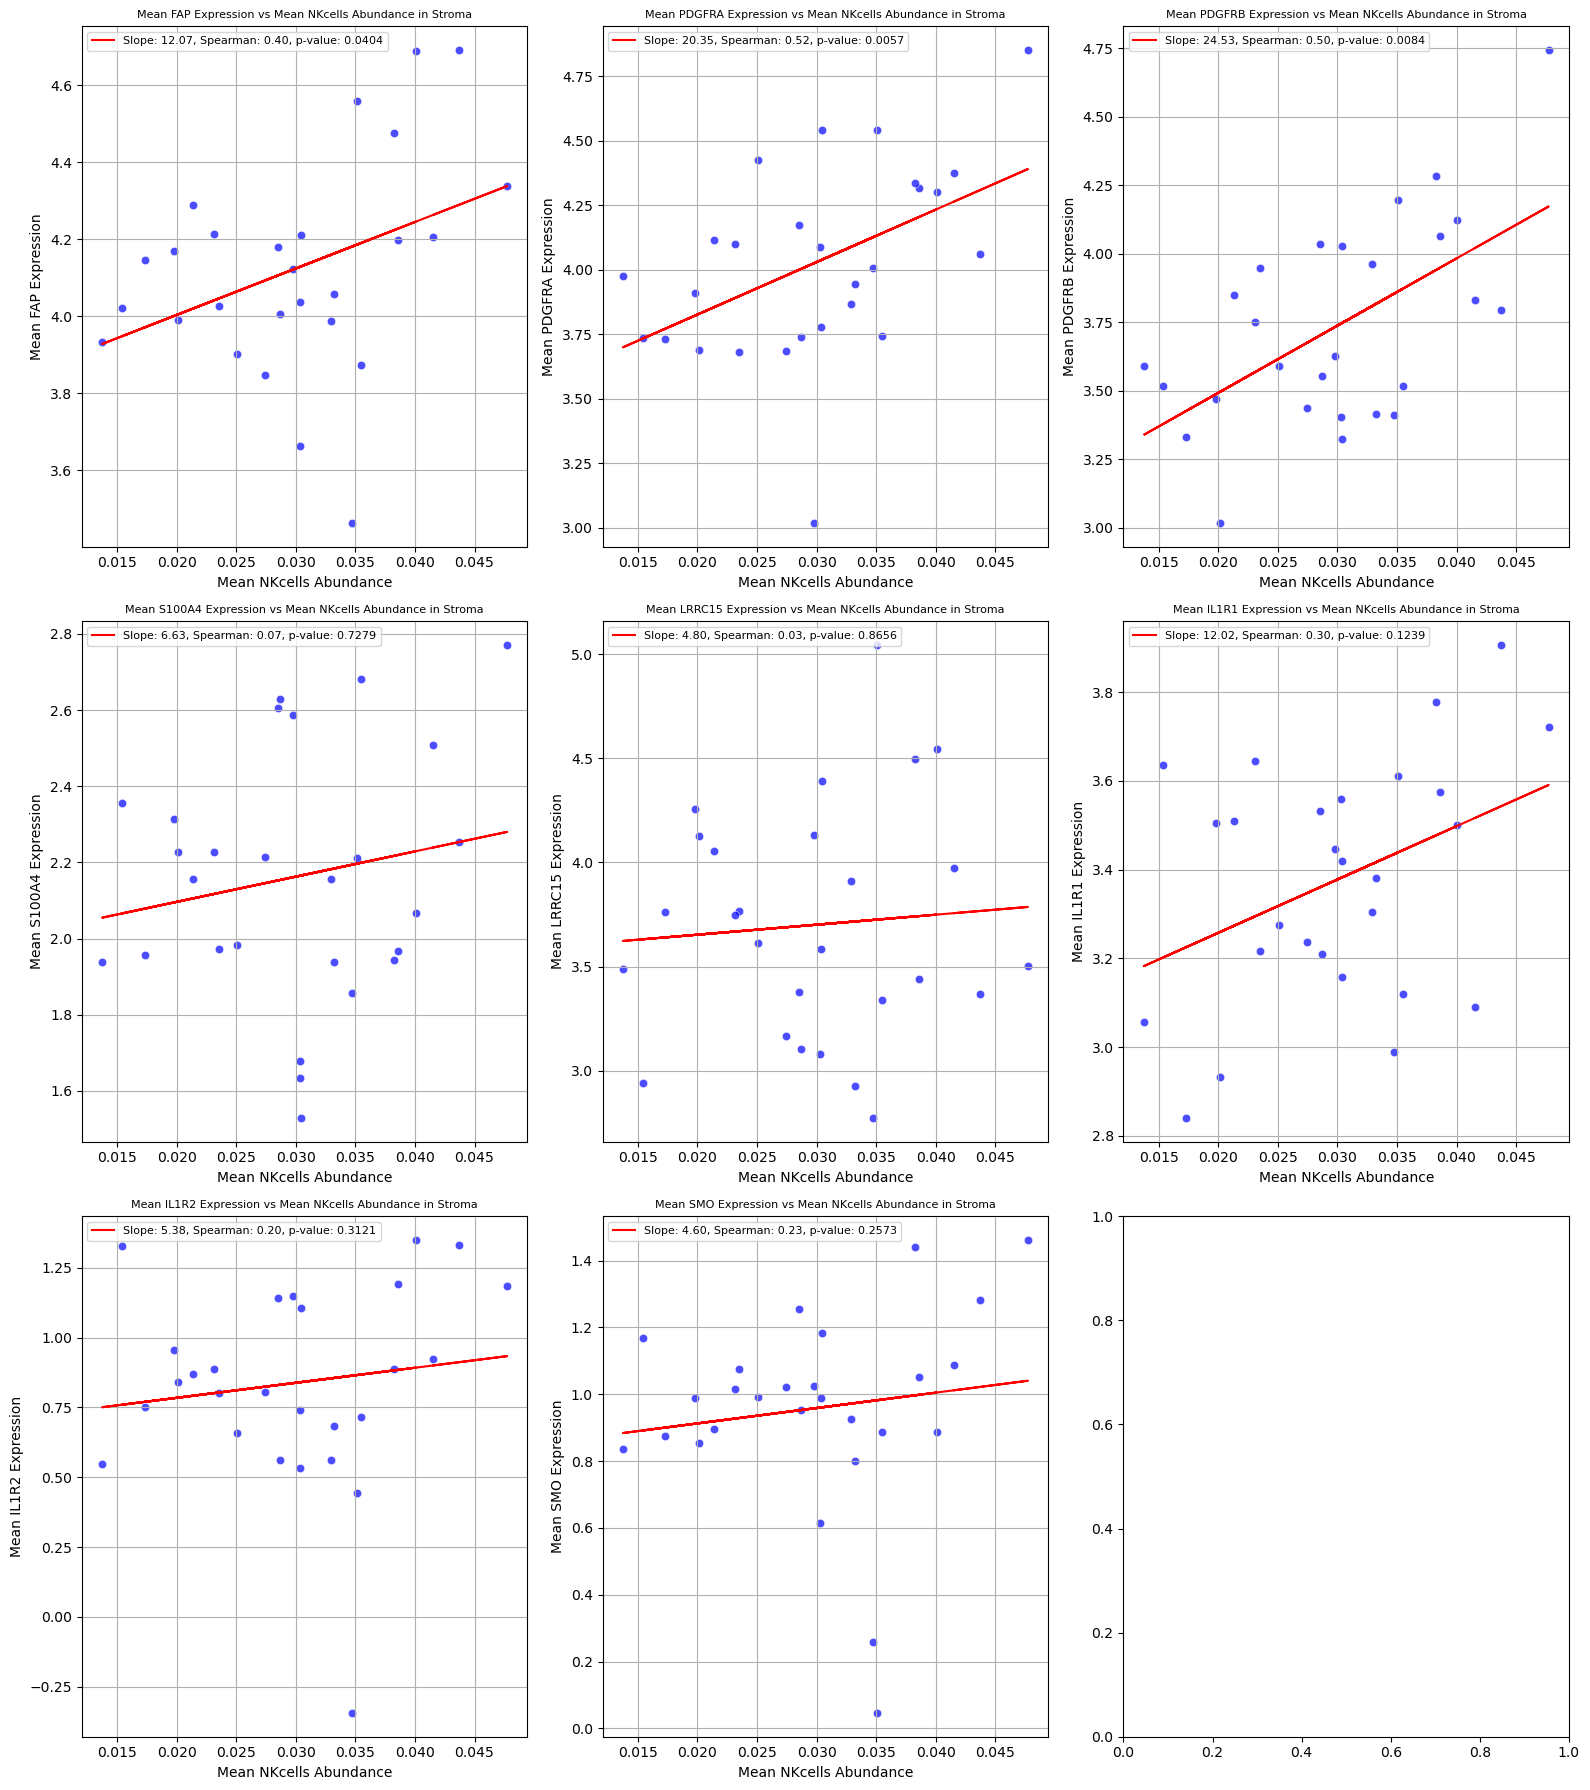

Spearman correlation for FAP vs Macrophages: -0.49
Spearman correlation for PDGFRA vs Macrophages: -0.30
Spearman correlation for PDGFRB vs Macrophages: -0.62
Spearman correlation for S100A4 vs Macrophages: -0.30
Spearman correlation for LRRC15 vs Macrophages: -0.30
Spearman correlation for IL1R1 vs Macrophages: -0.31
Spearman correlation for IL1R2 vs Macrophages: -0.35
Spearman correlation for SMO vs Macrophages: -0.31


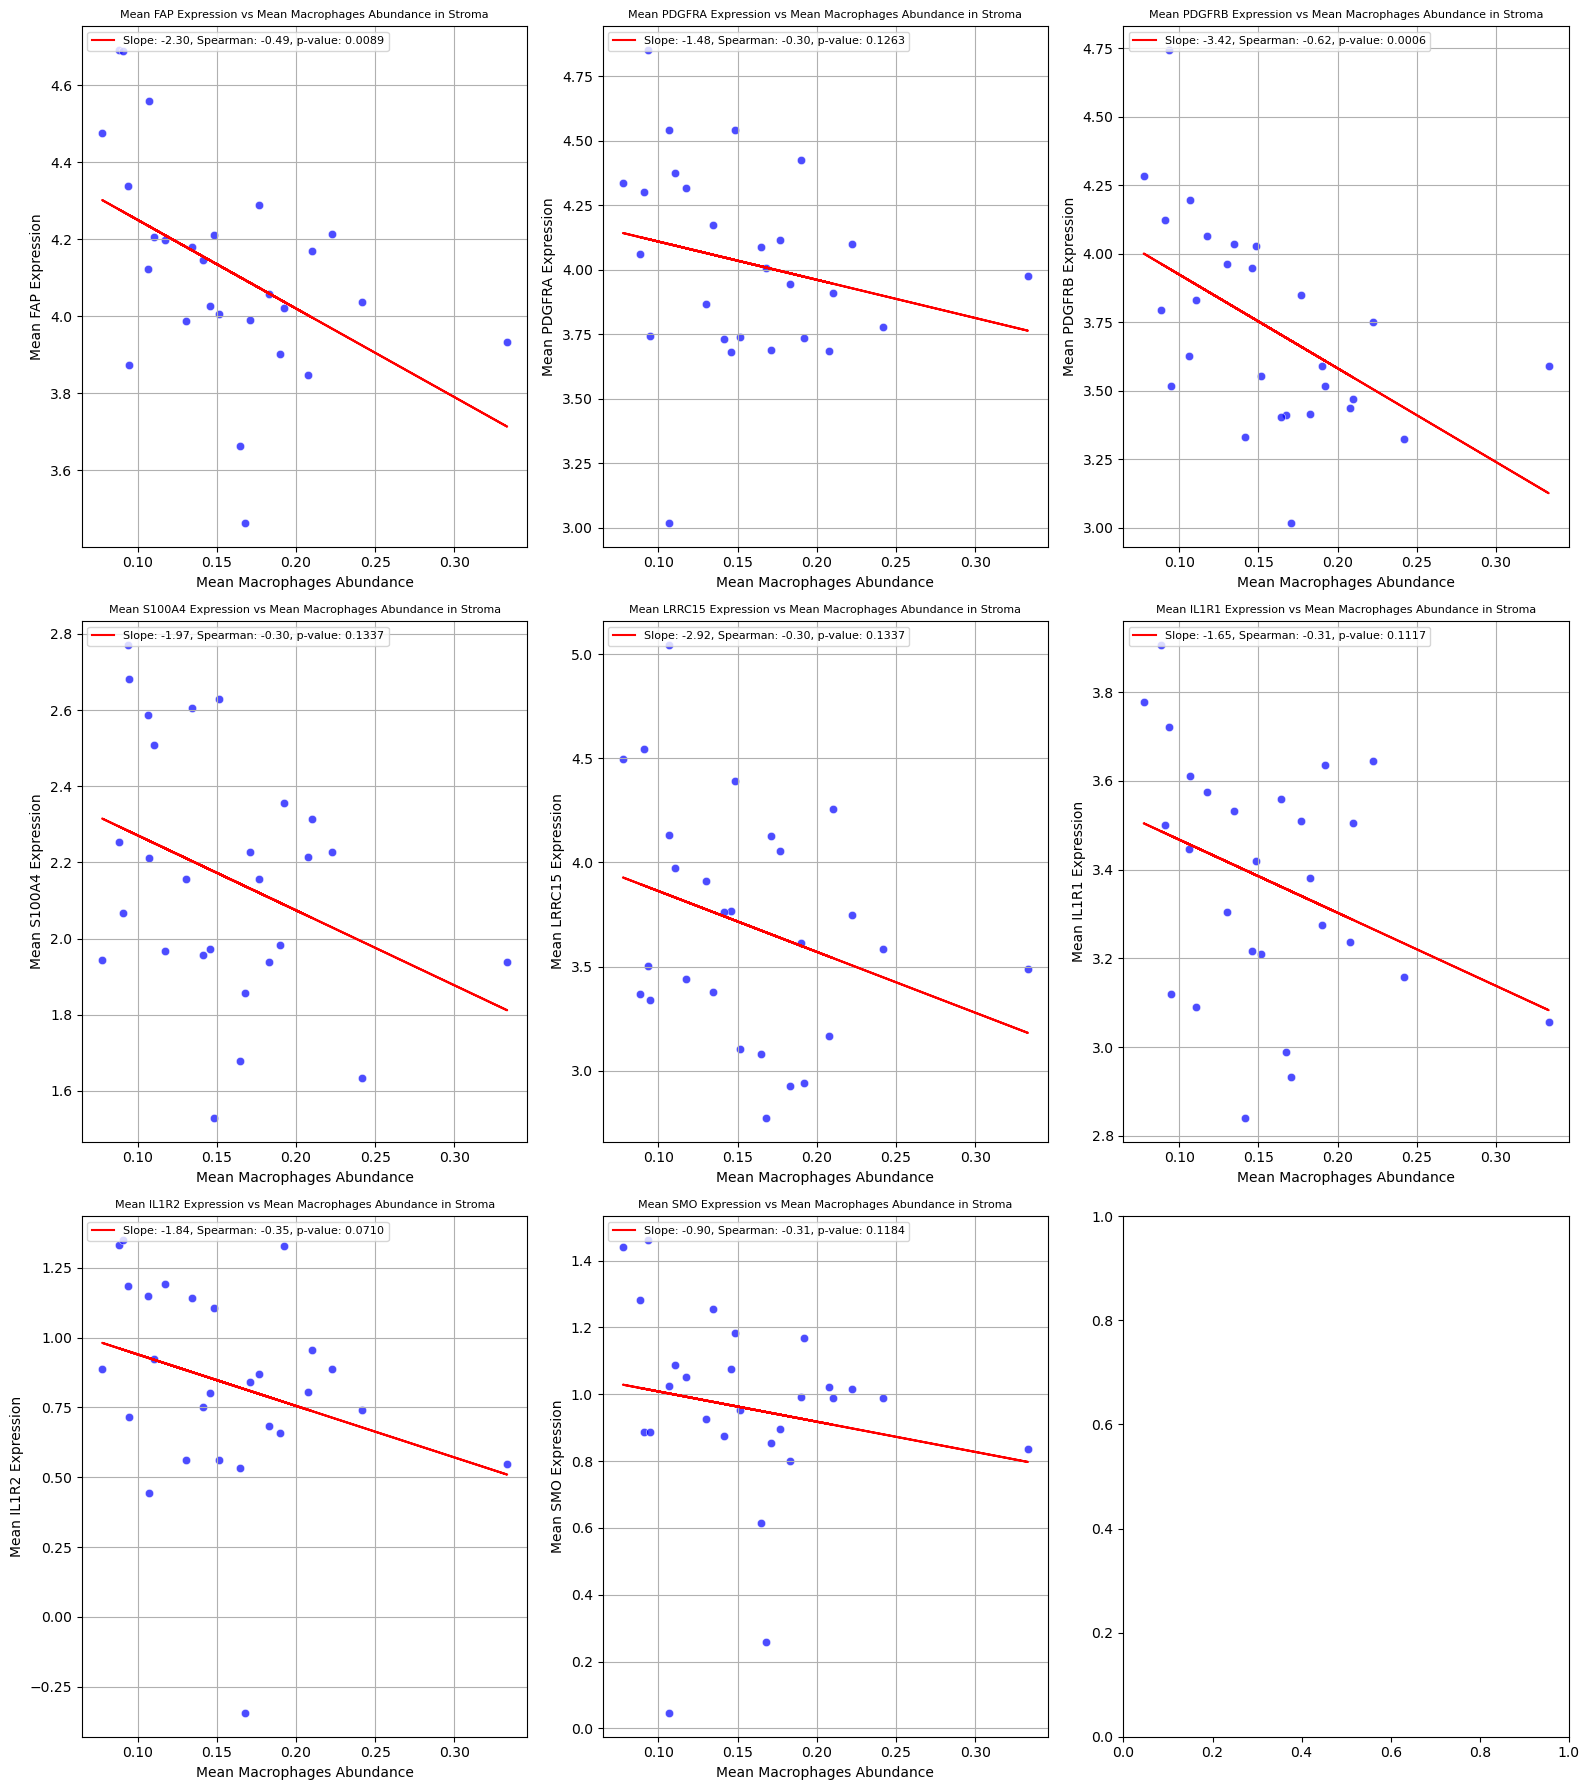

Spearman correlation for FAP vs Mast cells: nan
Spearman correlation for PDGFRA vs Mast cells: nan
Spearman correlation for PDGFRB vs Mast cells: nan
Spearman correlation for S100A4 vs Mast cells: nan
Spearman correlation for LRRC15 vs Mast cells: nan
Spearman correlation for IL1R1 vs Mast cells: nan
Spearman correlation for IL1R2 vs Mast cells: nan
Spearman correlation for SMO vs Mast cells: nan


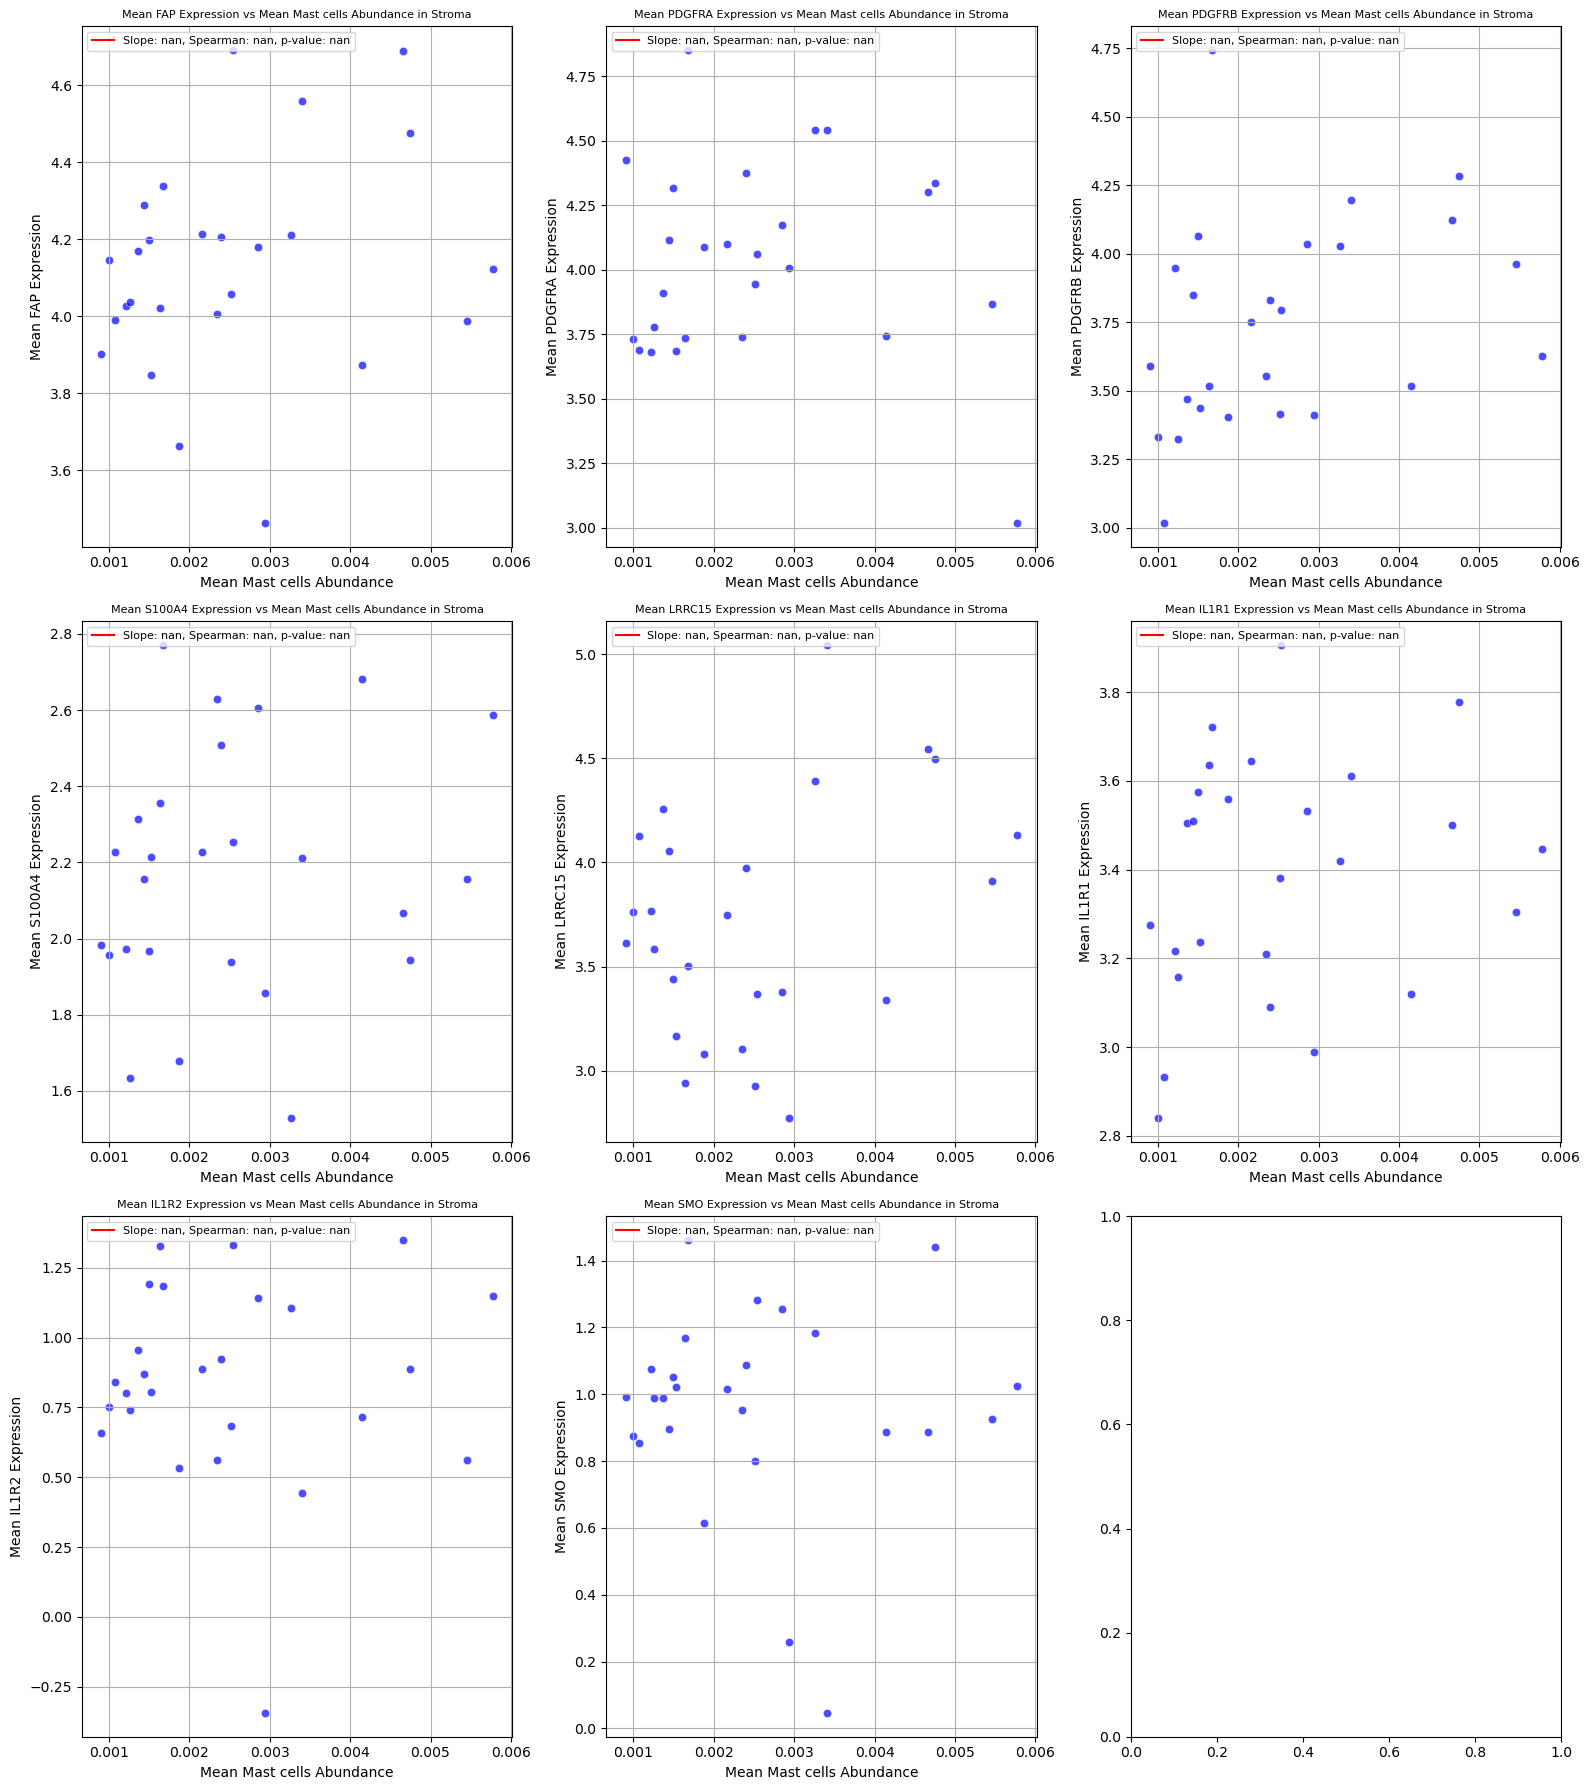

Spearman correlation for FAP vs DCs: 0.17
Spearman correlation for PDGFRA vs DCs: 0.15
Spearman correlation for PDGFRB vs DCs: 0.04
Spearman correlation for S100A4 vs DCs: -0.15
Spearman correlation for LRRC15 vs DCs: 0.04
Spearman correlation for IL1R1 vs DCs: 0.08
Spearman correlation for IL1R2 vs DCs: 0.03
Spearman correlation for SMO vs DCs: -0.11


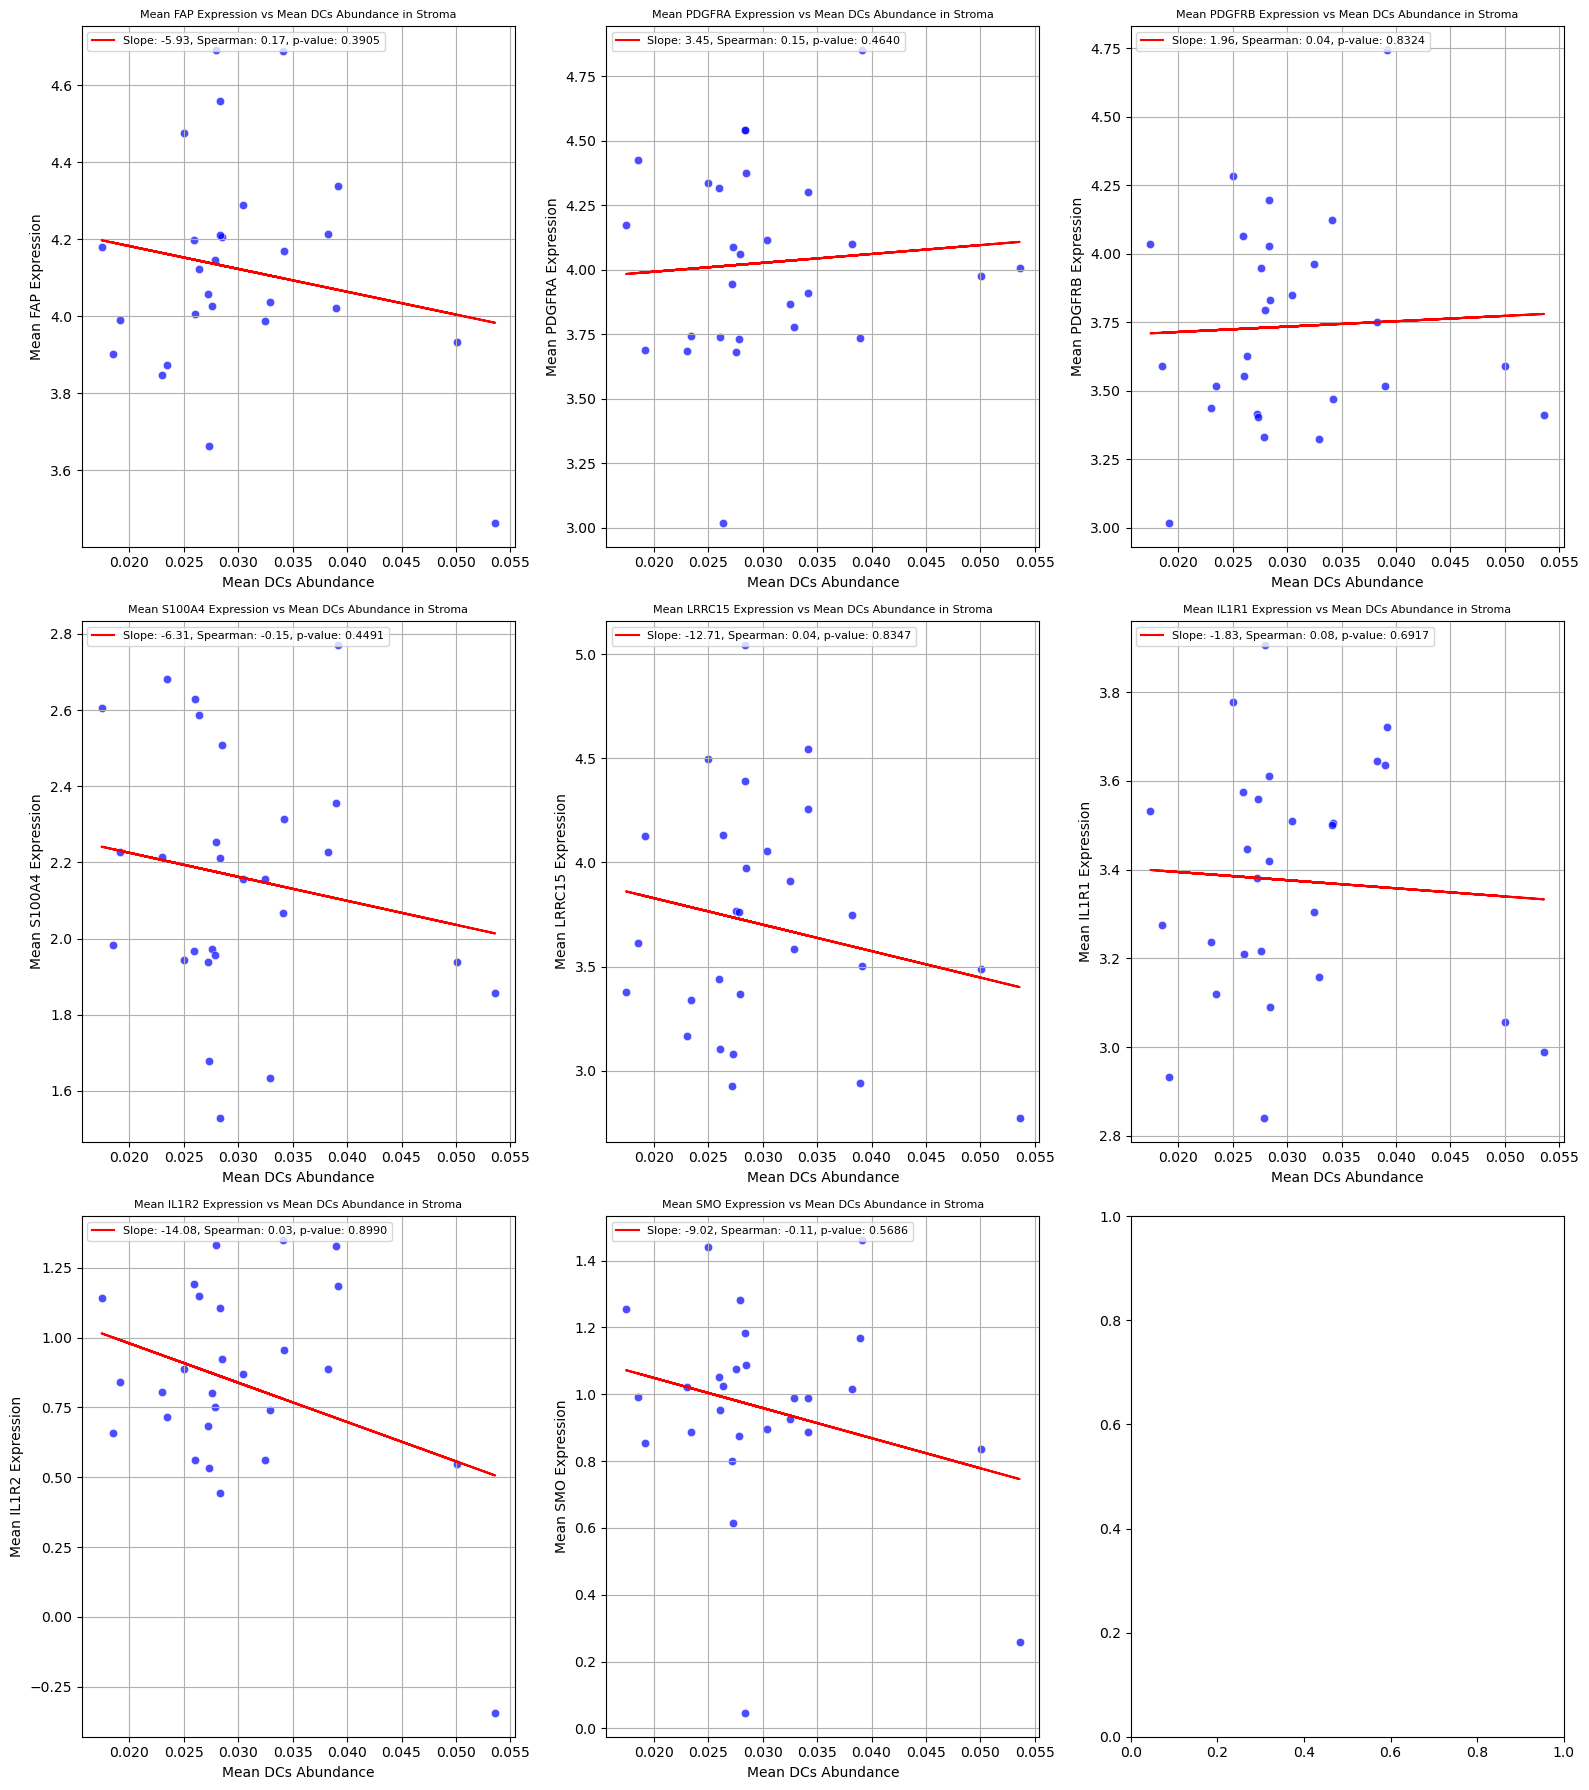

Spearman correlation for FAP vs other: nan
Spearman correlation for PDGFRA vs other: nan
Spearman correlation for PDGFRB vs other: nan
Spearman correlation for S100A4 vs other: nan
Spearman correlation for LRRC15 vs other: nan
Spearman correlation for IL1R1 vs other: nan
Spearman correlation for IL1R2 vs other: nan
Spearman correlation for SMO vs other: nan


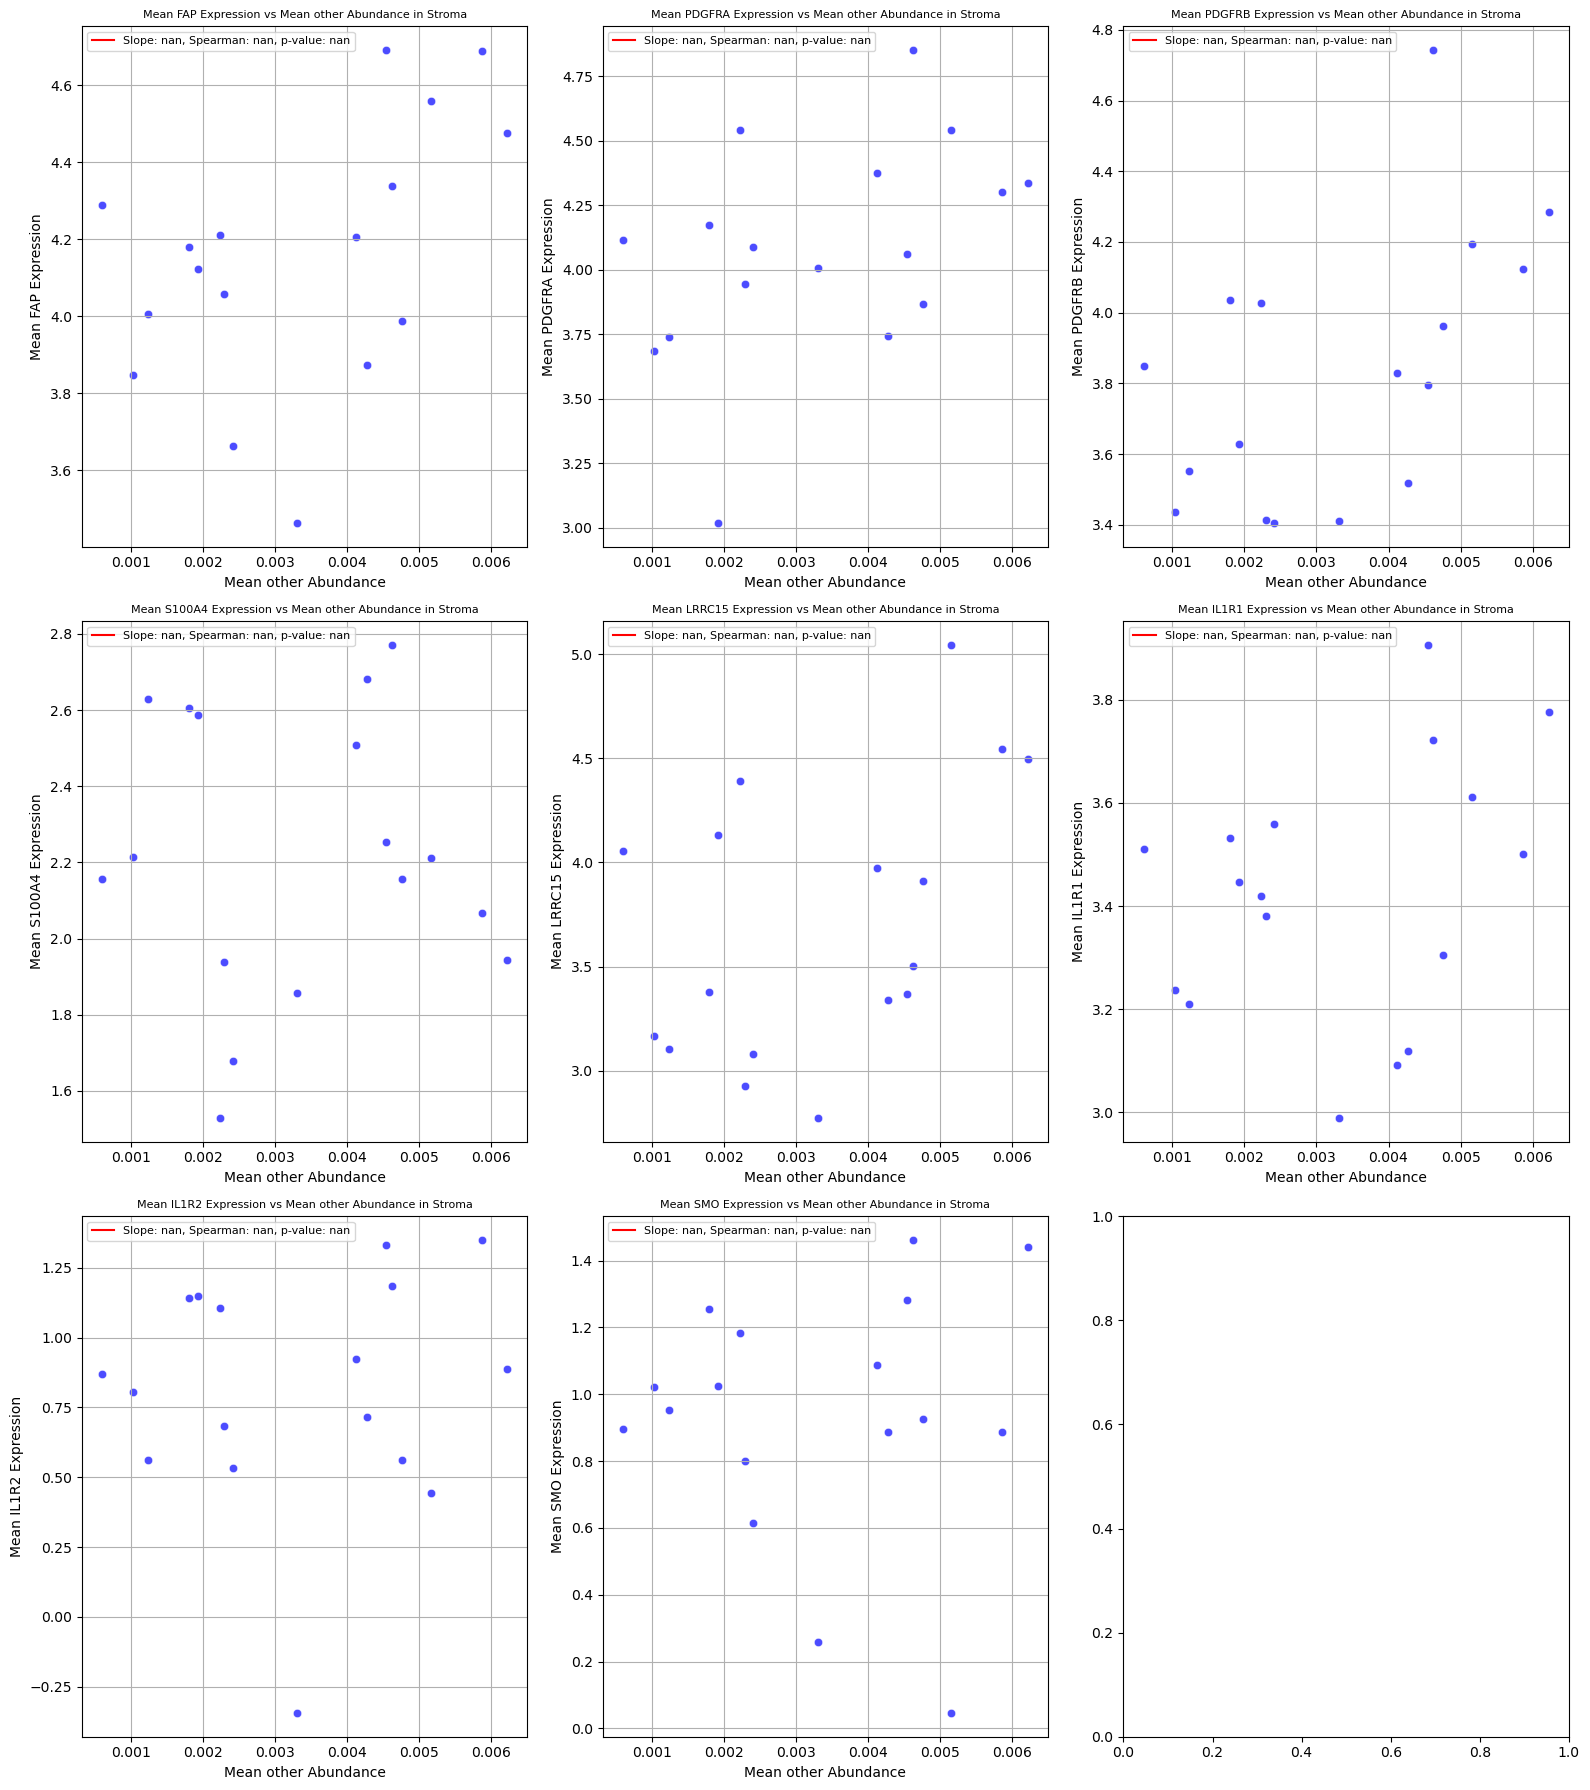

Spearman correlation for FAP vs Endothelial cells: -0.02
Spearman correlation for PDGFRA vs Endothelial cells: 0.33
Spearman correlation for PDGFRB vs Endothelial cells: 0.41
Spearman correlation for S100A4 vs Endothelial cells: -0.22
Spearman correlation for LRRC15 vs Endothelial cells: -0.05
Spearman correlation for IL1R1 vs Endothelial cells: 0.17
Spearman correlation for IL1R2 vs Endothelial cells: 0.05
Spearman correlation for SMO vs Endothelial cells: 0.15


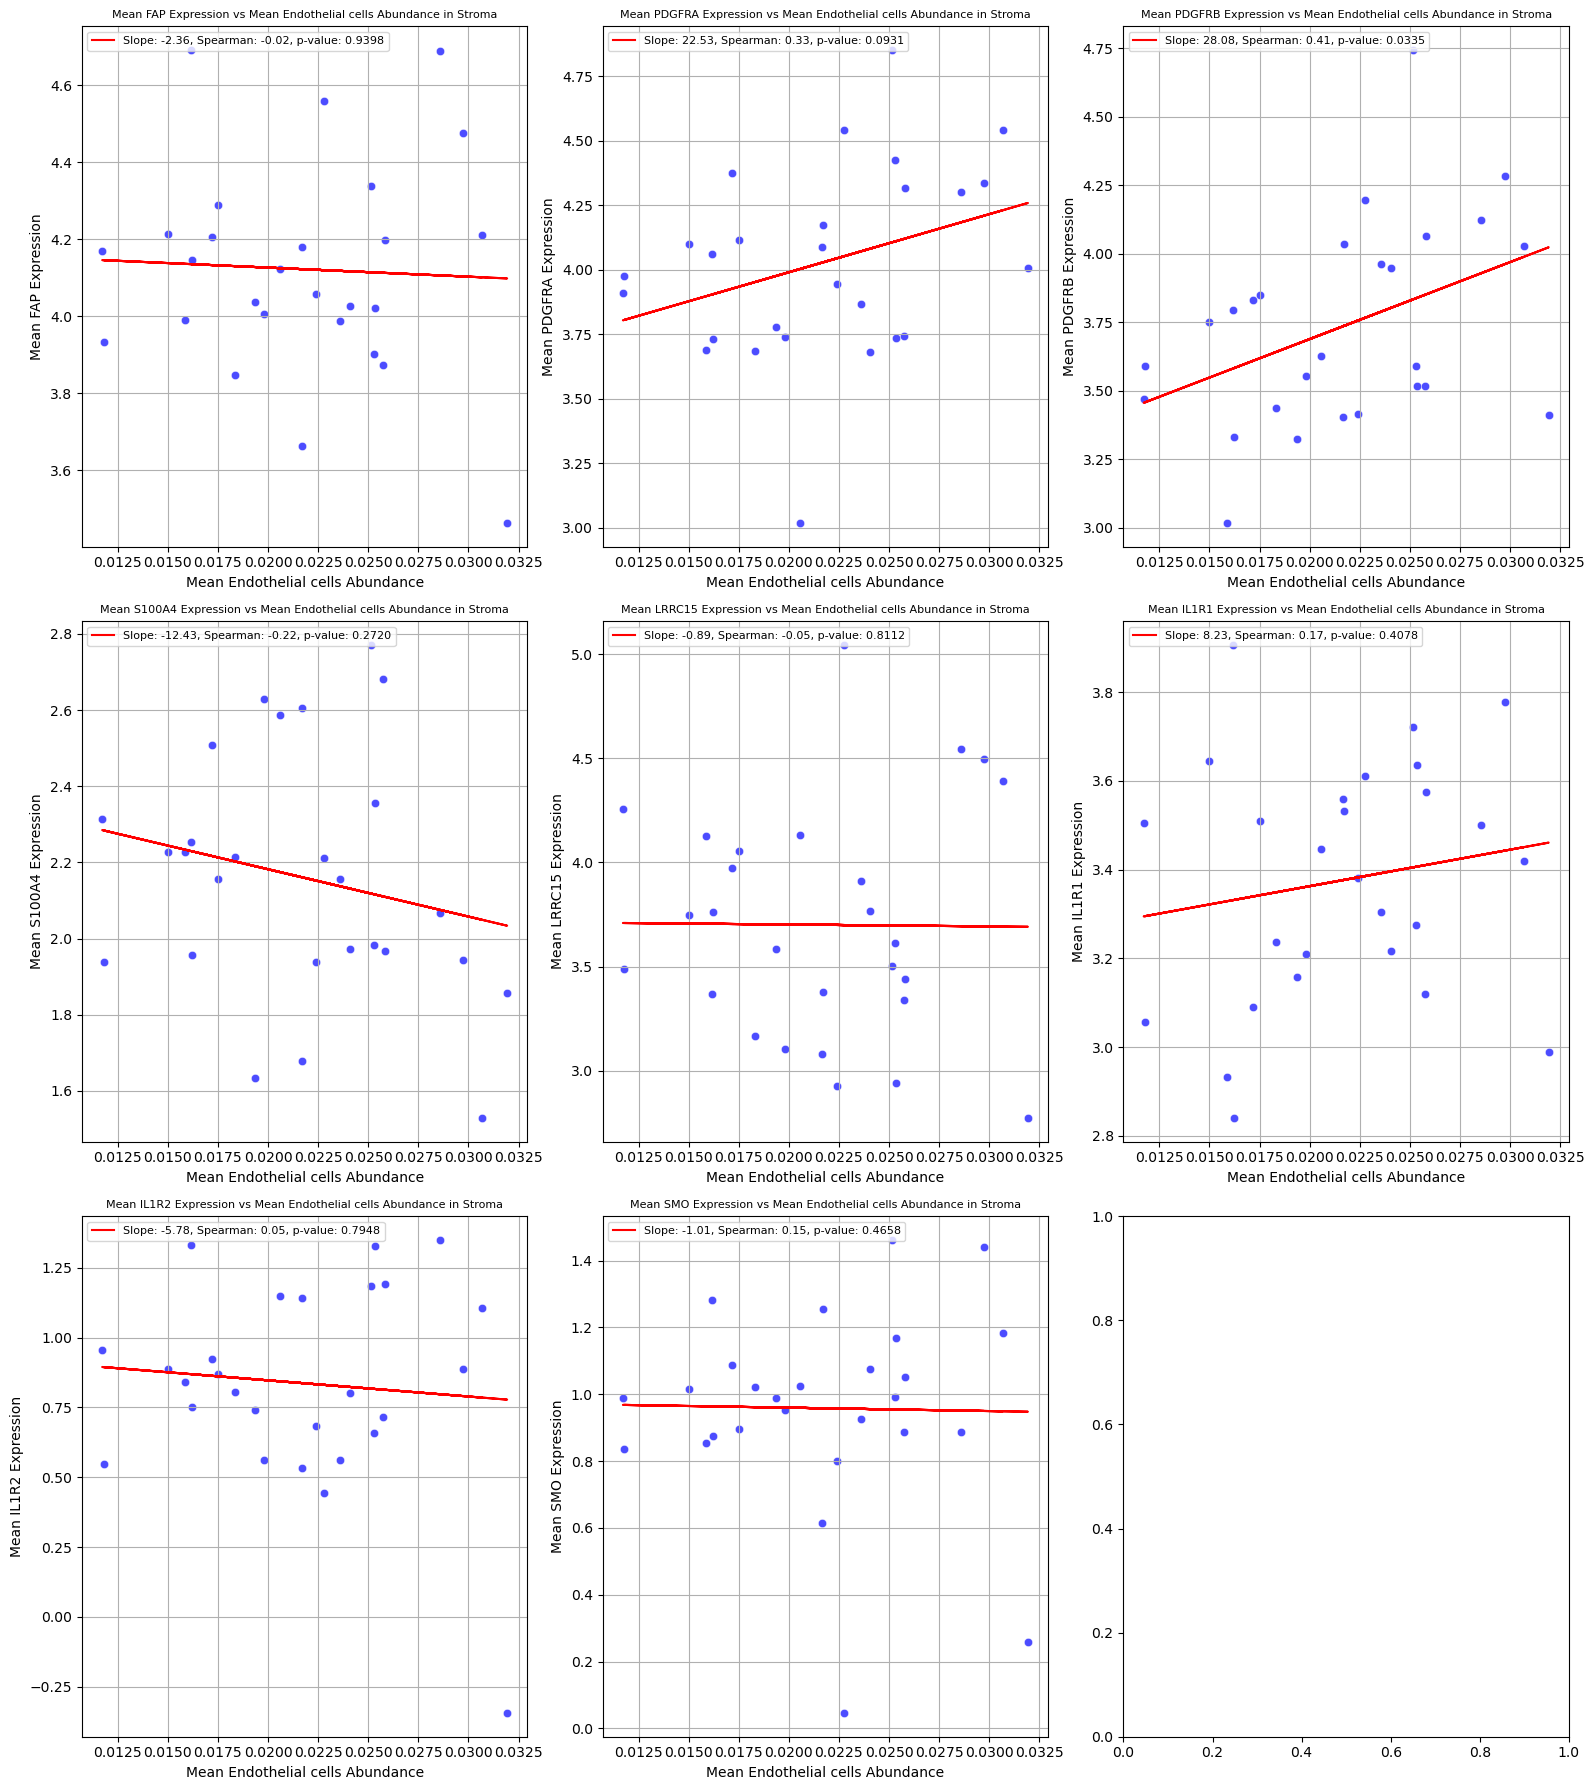

In [41]:
from scipy.stats import spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Set up the number of columns (3 plots per row)
ncols = 3

# Loop over each cell type to create individual plots
for cell in cell_types:
    # Determine the number of genes to plot for the current cell type
    num_genes = len(target_CAFs)

    # Set up the figure with subplots (3 columns, dynamic rows)
    nrows = (num_genes + ncols - 1) // ncols  # This ensures enough rows for all plots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 6))

    # Flatten axes array to easily index if there are multiple rows and columns
    axes = axes.flatten()

    for i, gene in enumerate(target_CAFs):
        # Check if there's enough space for the plot
        if i >= len(axes):
            break  # Prevent index errors if there are fewer genes than the number of subplots

        # Create a scatter plot for each gene vs. cell type
        sns.scatterplot(data=average_stroma_cell_abundance, x=cell, y=gene, color='blue', alpha=0.7, ax=axes[i])

        # Spearman correlation
        spearman_corr, pvalue = spearmanr(average_stroma_cell_abundance[cell], average_stroma_cell_abundance[gene])
        kendall_corr, _ = kendalltau(average_stroma_cell_abundance[cell], average_stroma_cell_abundance[gene])
        print(f"Spearman correlation for {gene} vs {cell}: {spearman_corr:.2f}")

        # Linear regression
        slope, intercept, _, _, _ = linregress(average_stroma_cell_abundance[cell], average_stroma_cell_abundance[gene])
        regression_line = slope * average_stroma_cell_abundance[cell] + intercept
        axes[i].plot(average_stroma_cell_abundance[cell], regression_line, label=f'Slope: {slope:.2f}, Spearman: {spearman_corr:.2f}, p-value: {pvalue:.4f}', color='red')

        # Plot formatting
        axes[i].set_title(f"Mean {gene} Expression vs Mean {cell} Abundance in Stroma", fontsize=8)
        axes[i].set_xlabel(f"Mean {cell} Abundance")
        axes[i].set_ylabel(f"Mean {gene} Expression")
        axes[i].grid()

        # Add legend for each plot
        axes[i].legend(loc='upper left', fontsize=8)

    # Adjust layout to prevent overlap and ensure that labels are visible
    plt.tight_layout()

    # Show the figure for the current cell type
    plt.show()


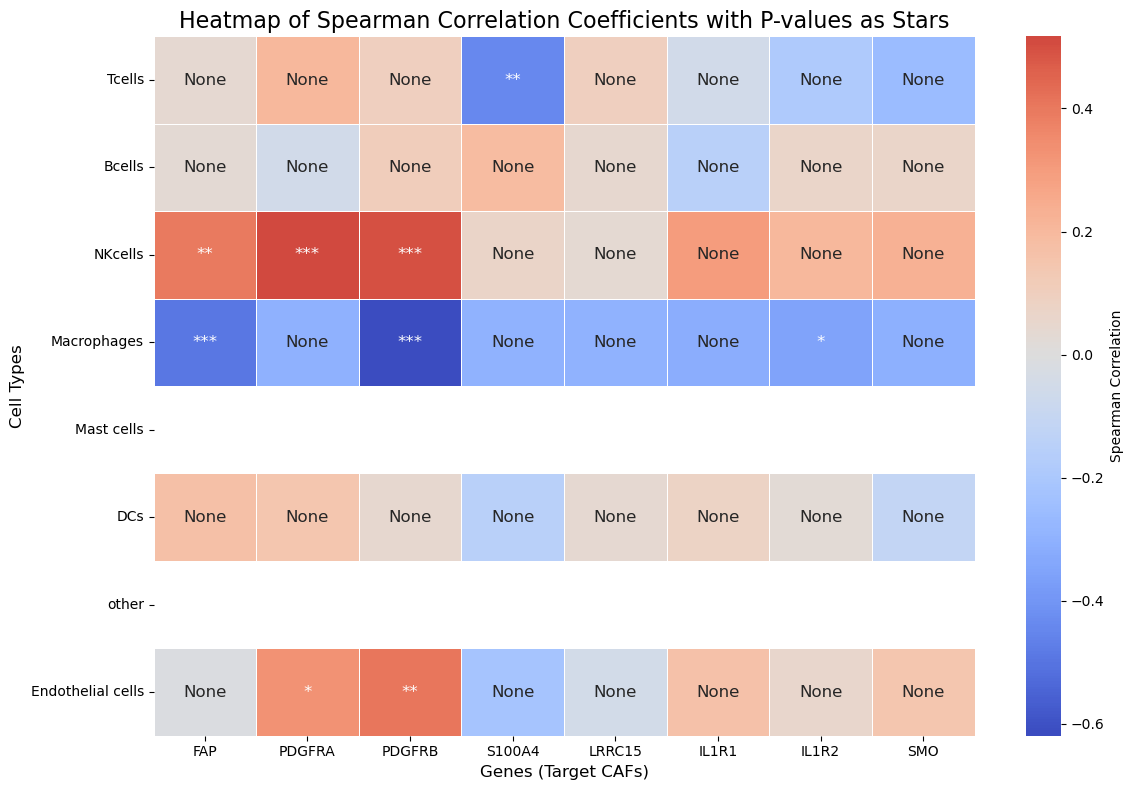

In [42]:

# Initialize empty lists to store correlation coefficients and p-values
correlation_matrix = []
p_value_matrix = []

# Loop over cell types and target genes to compute correlation coefficients and p-values
for cell in cell_types:
    corr_row = []
    p_value_row = []
    
    for gene in target_CAFs:
        # Calculate the Spearman correlation and p-value
        spearman_corr, p_value = spearmanr(average_stroma_cell_abundance[cell], average_stroma_cell_abundance[gene])

        # Append the correlation and p-value to the respective rows
        corr_row.append(spearman_corr)
        p_value_row.append(p_value)
    
    # Append each row of correlations and p-values to the matrices
    correlation_matrix.append(corr_row)
    p_value_matrix.append(p_value_row)

# Convert the correlation and p-value matrices to numpy arrays for easier manipulation
correlation_matrix = np.array(correlation_matrix)
p_value_matrix = np.array(p_value_matrix)

# Create a matrix of stars based on p-value thresholds
star_matrix = np.empty_like(p_value_matrix, dtype=object)
for i in range(p_value_matrix.shape[0]):
    for j in range(p_value_matrix.shape[1]):
        p_val = p_value_matrix[i, j]
        if p_val < 0.01:
            star_matrix[i, j] = "***"
        elif p_val < 0.05:
            star_matrix[i, j] = "**"
        elif p_val < 0.1:
            star_matrix[i, j] = "*"
        

# Create a heatmap for the correlation coefficients
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=star_matrix, fmt='', cmap='coolwarm', center=0, 
            xticklabels=target_CAFs, yticklabels=cell_types, annot_kws={'size': 12}, 
            cbar_kws={'label': 'Spearman Correlation'}, linewidths=0.5)

# Customize the plot
plt.title("Heatmap of Spearman Correlation Coefficients with P-values as Stars", fontsize=16)
plt.xlabel("Genes (Target CAFs)", fontsize=12)
plt.ylabel("Cell Types", fontsize=12)
plt.tight_layout()
plt.show()


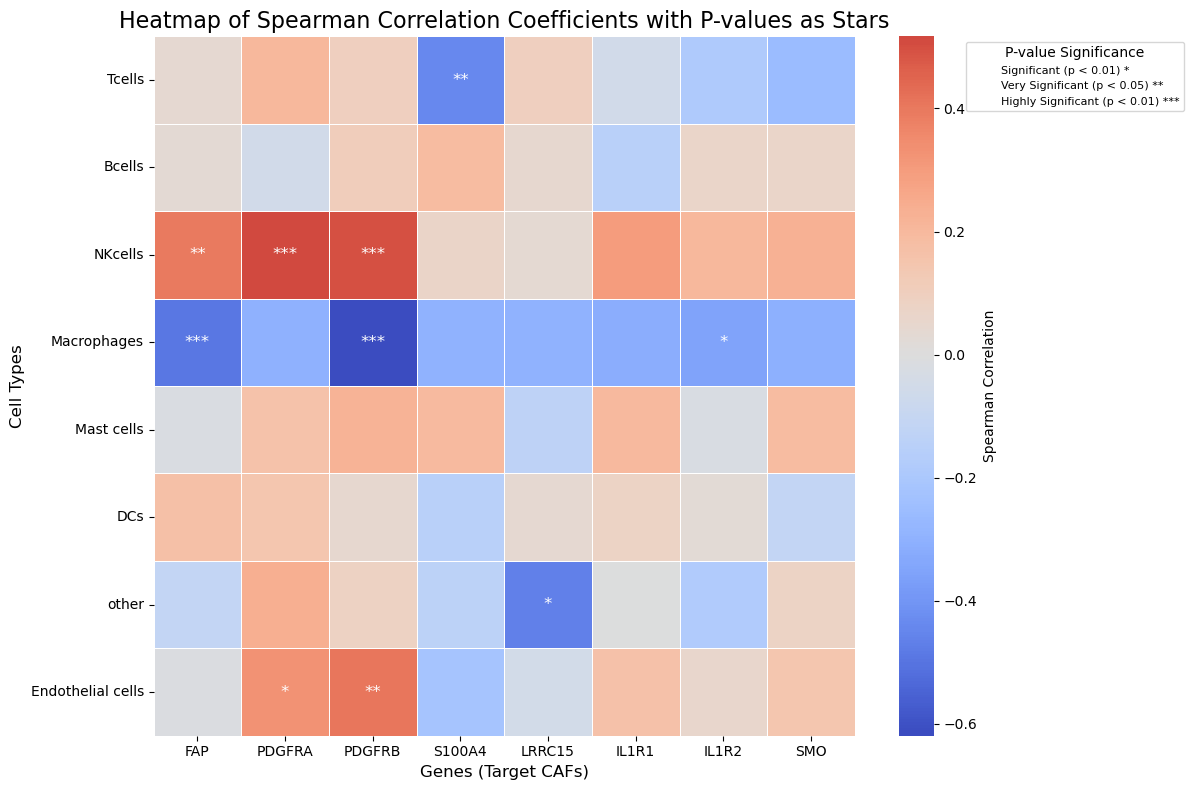

In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Initialize empty lists to store correlation coefficients and p-values
correlation_matrix = []
p_value_matrix = []

# Loop over cell types and target genes to compute correlation coefficients and p-values
for cell in cell_types:
    corr_row = []
    p_value_row = []
    
    for gene in target_CAFs:
        # Remove NaN values from both cell and gene columns
        cell_data = average_stroma_cell_abundance[cell].dropna()
        gene_data = average_stroma_cell_abundance[gene].dropna()

        # Make sure the lengths of the two arrays match after dropping NaN values
        min_length = min(len(cell_data), len(gene_data))
        cell_data = cell_data[:min_length]
        gene_data = gene_data[:min_length]

        # Calculate the Spearman correlation and p-value
        spearman_corr, p_value = spearmanr(cell_data, gene_data)

        # Append the correlation and p-value to the respective rows
        corr_row.append(spearman_corr)
        p_value_row.append(p_value)
    
    # Append each row of correlations and p-values to the matrices
    correlation_matrix.append(corr_row)
    p_value_matrix.append(p_value_row)

# Convert the correlation and p-value matrices to numpy arrays for easier manipulation
correlation_matrix = np.array(correlation_matrix)
p_value_matrix = np.array(p_value_matrix)

# Create a matrix of stars based on p-value thresholds
star_matrix = np.empty_like(p_value_matrix, dtype=object)
for i in range(p_value_matrix.shape[0]):
    for j in range(p_value_matrix.shape[1]):
        p_val = p_value_matrix[i, j]
        if p_val < 0.01:
            star_matrix[i, j] = "***"
        elif p_val < 0.05:
            star_matrix[i, j] = "**"
        elif p_val < 0.1:
            star_matrix[i, j] = "*"
        else:
            star_matrix[i, j] = ""  # Leave empty for non-significant values

# Create a heatmap for the correlation coefficients
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=star_matrix, fmt='', cmap='coolwarm', center=0, 
            xticklabels=target_CAFs, yticklabels=cell_types, annot_kws={'size': 12}, 
            cbar_kws={'label': 'Spearman Correlation'}, linewidths=0.5)

# Customize the plot
plt.title("Heatmap of Spearman Correlation Coefficients with P-values as Stars", fontsize=16)
plt.xlabel("Genes (Target CAFs)", fontsize=12)
plt.ylabel("Cell Types", fontsize=12)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='', color='w', markerfacecolor='black', markersize=10, label='Significant (p < 0.01) *'),
    Line2D([0], [0], marker='', color='w', markerfacecolor='black', markersize=10, label='Very Significant (p < 0.05) **'),
    Line2D([0], [0], marker='', color='w', markerfacecolor='black', markersize=10, label='Highly Significant (p < 0.01) ***')
]

plt.legend( handles=legend_elements,loc="upper left", fontsize=8, bbox_to_anchor=(1.15, 1),title="P-value Significance")


plt.tight_layout()
plt.show()


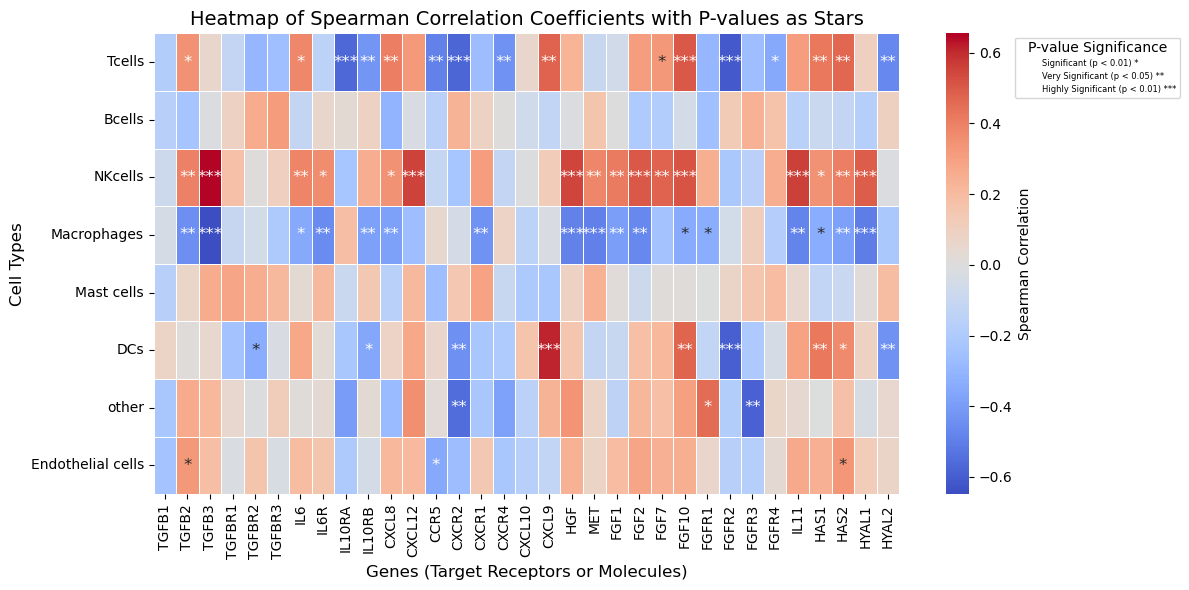

In [44]:
correlation_matrix = []
p_value_matrix = []

# Loop over cell types and target genes to compute correlation coefficients and p-values
for cell in cell_types:
    corr_row = []
    p_value_row = []
    
    for gene in target_receptors_molecules:
        # Remove NaN values from both cell and gene columns
        cell_data = average_stroma_cell_abundance[cell].dropna()
        gene_data = average_stroma_cell_abundance[gene].dropna()

        # Make sure the lengths of the two arrays match after dropping NaN values
        min_length = min(len(cell_data), len(gene_data))
        cell_data = cell_data[:min_length]
        gene_data = gene_data[:min_length]

        # Calculate the Spearman correlation and p-value
        spearman_corr, p_value = spearmanr(cell_data, gene_data)

        # Append the correlation and p-value to the respective rows
        corr_row.append(spearman_corr)
        p_value_row.append(p_value)
    
    # Append each row of correlations and p-values to the matrices
    correlation_matrix.append(corr_row)
    p_value_matrix.append(p_value_row)

# Convert the correlation and p-value matrices to numpy arrays for easier manipulation
correlation_matrix = np.array(correlation_matrix)
p_value_matrix = np.array(p_value_matrix)

# Create a matrix of stars based on p-value thresholds
star_matrix = np.empty_like(p_value_matrix, dtype=object)
for i in range(p_value_matrix.shape[0]):
    for j in range(p_value_matrix.shape[1]):
        p_val = p_value_matrix[i, j]
        if p_val < 0.01:
            star_matrix[i, j] = "***"
        elif p_val < 0.05:
            star_matrix[i, j] = "**"
        elif p_val < 0.1:
            star_matrix[i, j] = "*"
        else:
            star_matrix[i, j] = ""  # Leave empty for non-significant values

# Create a heatmap for the correlation coefficients
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=star_matrix, fmt='', cmap='coolwarm', center=0, 
            xticklabels=target_receptors_molecules, yticklabels=cell_types, annot_kws={'size': 12}, 
            cbar_kws={'label': 'Spearman Correlation'}, linewidths=0.5)

# Customize the plot
plt.title("Heatmap of Spearman Correlation Coefficients with P-values as Stars", fontsize=14)
plt.xlabel("Genes (Target Receptors or Molecules)", fontsize=12)
plt.ylabel("Cell Types", fontsize=12)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='', color='w', markerfacecolor='black', markersize=10, label='Significant (p < 0.01) *'),
    Line2D([0], [0], marker='', color='w', markerfacecolor='black', markersize=10, label='Very Significant (p < 0.05) **'),
    Line2D([0], [0], marker='', color='w', markerfacecolor='black', markersize=10, label='Highly Significant (p < 0.01) ***')
]

plt.legend( handles=legend_elements,loc="upper left", fontsize=6, bbox_to_anchor=(1.15, 1),title="P-value Significance")


plt.tight_layout()
plt.show()
